In [1]:
# ============================================================
# TASK 1 - Data Ingestion Pipeline & Exploratory Analysis
# RenewCred EV Telemetry Intelligence
# ============================================================

import json
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import folium
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

SECRET_SALT = os.getenv("SECRET_SALT")
print("✅ Salt loaded successfully")

✅ Salt loaded successfully


In [3]:
# ============================================================
# SECTION 1.1 - Parse & Flatten the MQTT Payload
# ============================================================

import hashlib


def anonymise_imei(imei: str) -> str:
    """Hash IMEI using SHA-256 with salt - never store raw IMEI"""
    if pd.isna(imei) or imei == "":
        return None
    salted = f"{imei}{SECRET_SALT}".encode('utf-8')
    return hashlib.sha256(salted).hexdigest()

def parse_ev_payload(raw_csv_path: str) -> pd.DataFrame:
    """
    Parse raw MQTT CSV → clean flat DataFrame.
    Handles: malformed JSON, duplicate timestamps,
    missing battery/GPS nested objects, epoch-ms → UTC conversion.
    Returns DataFrame with all 21 columns from field reference.
    """
    
    # Load raw CSV
    print(f"📂 Loading file: {raw_csv_path}")
    raw_df = pd.read_csv(raw_csv_path)
    print(f"✅ Raw shape: {raw_df.shape}")
    print(f"📋 Raw columns: {list(raw_df.columns)}")
    
    return raw_df

# Run it
RAW_CSV_PATH = "../data/raw/EV _ Sample data - data-1773851228982 - EV.csv"
raw_df = parse_ev_payload(RAW_CSV_PATH)
raw_df.head()

📂 Loading file: ../data/raw/EV _ Sample data - data-1773851228982 - EV.csv
✅ Raw shape: (21409, 6)
📋 Raw columns: ['topic', 'payload', 'created_timestamp', 'Unnamed: 3', 'topic.1', 'payload.1']


,topic,payload,created_timestamp,Unnamed: 3,topic.1,payload.1
0,ev.3w.telemetry,"{\n ""payload"": {""deviceId"":""TEC0425A0600006"",...",46:31.2,NaN,ev.3w.telemetry,"{\n ""payload"": {""deviceId"":""TEC0425A0600006"",..."
1,ev.3w.telemetry,"{\n ""payload"": {""deviceId"":""TEC0425A0600006"",...",46:31.2,NaN,ev.3w.telemetry,"{\n ""payload"": {""deviceId"":""TEC0425A0600006"",..."
2,ev.3w.telemetry,"{\n ""payload"": {""deviceId"":""TEC0325A0600002"",...",46:31.2,NaN,ev.3w.telemetry,"{\n ""payload"": {""deviceId"":""TEC0325A0600002"",..."
3,ev.3w.telemetry,"{\n ""payload"": {""deviceId"":""TEC0325A0600002"",...",46:31.2,NaN,ev.3w.telemetry,"{\n ""payload"": {""deviceId"":""TEC0325A0600002"",..."
4,ev.3w.telemetry,"{\n ""payload"": {""deviceId"":""TEC0325A0600002"",...",46:31.2,NaN,ev.3w.telemetry,"{\n ""payload"": {""deviceId"":""TEC0325A0600002"",..."


In [4]:
# ============================================================
# Inspect raw data before parsing
# ============================================================

# Check for duplicate columns
print("🔍 First few rows of payload column:")
print(raw_df['payload'].head(3))

print("\n🔍 First few rows of payload.1 column:")
print(raw_df['payload.1'].head(3))

print("\n🔍 Unnamed column sample:")
print(raw_df['Unnamed: 3'].head(3))

print("\n🔍 Null counts per column:")
print(raw_df.isnull().sum())

🔍 First few rows of payload column:
0    {\n  "payload": {"deviceId":"TEC0425A0600006",...
1    {\n  "payload": {"deviceId":"TEC0425A0600006",...
2    {\n  "payload": {"deviceId":"TEC0325A0600002",...
Name: payload, dtype: object

🔍 First few rows of payload.1 column:
0    {\n  "payload": {"deviceId":"TEC0425A0600006",...
1    {\n  "payload": {"deviceId":"TEC0425A0600006",...
2    {\n  "payload": {"deviceId":"TEC0325A0600002",...
Name: payload.1, dtype: object

🔍 Unnamed column sample:
0   NaN
1   NaN
2   NaN
Name: Unnamed: 3, dtype: float64

🔍 Null counts per column:
topic                    0
payload                  0
created_timestamp        0
Unnamed: 3           21409
topic.1                  0
payload.1                0
dtype: int64


In [5]:
# ============================================================
# SECTION 1.1 - Full Payload Parser
# ============================================================

from dotenv import load_dotenv
import os

load_dotenv()
SECRET_SALT = os.getenv("SECRET_SALT")

def anonymise_imei(imei):
    """Hash IMEI using SHA-256 with salt"""
    if pd.isna(imei) or str(imei).strip() == "":
        return None
    salted = f"{str(imei)}{SECRET_SALT}".encode('utf-8')
    return hashlib.sha256(salted).hexdigest()

def parse_single_payload(raw_json_str):
    """
    Parse a single JSON string from payload column.
    Returns a flat dict with all 21 fields.
    Returns None if malformed.
    """
    try:
        # Parse outer JSON
        outer = json.loads(raw_json_str)
        
        # Get inner payload
        p = outer.get('payload', {})
        
        # Get nested objects safely
        gps = p.get('gps', {}) or {}
        battery = p.get('battery', {}) or {}
        
        return {
            # Device info
            'device_id':            p.get('deviceId'),
            'imei_token':           anonymise_imei(p.get('imei')),
            'last_ping_time':       p.get('lastPingTime'),
            'device_status':        p.get('status'),
            
            # GPS fields
            'gps_lat':              gps.get('gpsLatitude'),
            'gps_lon':              gps.get('gpsLongitude'),
            'gps_speed_kmh':        gps.get('gpsGroundSpeed'),
            'gps_delta_km':         gps.get('gpsGroundDeltaDistance'),
            'gps_total_km':         gps.get('gpsTotalGroundDistance'),
            
            # Battery fields
            'battery_state':        battery.get('batteryState'),
            'battery_soc_pct':      battery.get('batterySoc'),
            'battery_capacity_ah':  battery.get('batteryInstalledCapacity'),
            'battery_usable_ah':    battery.get('batteryUsableCapacity'),
            'capacity_discharge_ah':battery.get('batteryCapacityToDischarge'),
            'capacity_charge_ah':   battery.get('batteryCapacityToCharge'),
            'battery_voltage_v':    battery.get('batteryVoltage'),
            'cell_voltage_min':     battery.get('batteryMinCellVoltage'),
            'cell_voltage_max':     battery.get('batteryMaxCellVoltage'),
            'battery_temp_c':       battery.get('batteryAvgTemp'),
            'battery_soh_pct':      battery.get('batterySoh'),
            
            # Timestamp
            'ts':                   outer.get('timestamp'),
        }
    except Exception as e:
        # Malformed row — skip it
        return None

def parse_ev_payload(raw_csv_path: str) -> pd.DataFrame:
    """
    Full pipeline: raw CSV → clean flat DataFrame
    """
    # Load raw CSV
    print(f"📂 Loading: {raw_csv_path}")
    raw_df = pd.read_csv(raw_csv_path)
    print(f"✅ Raw shape: {raw_df.shape}")
    
    # Drop useless columns
    raw_df = raw_df.drop(columns=['Unnamed: 3', 'topic.1', 'payload.1'], errors='ignore')
    print(f"✅ Dropped duplicate/empty columns")
    
    # Parse each payload row
    print(f"⏳ Parsing {len(raw_df)} rows...")
    parsed_rows = []
    malformed_count = 0
    
    for idx, row in raw_df.iterrows():
        result = parse_single_payload(row['payload'])
        if result is not None:
            parsed_rows.append(result)
        else:
            malformed_count += 1
    
    print(f"✅ Successfully parsed: {len(parsed_rows)} rows")
    print(f"⚠️  Malformed/skipped rows: {malformed_count}")
    
    # Build DataFrame
    df = pd.DataFrame(parsed_rows)
    
    # Convert timestamp epoch-ms → UTC datetime
    df['ts'] = pd.to_datetime(df['ts'], unit='ms', utc=True)
    
    # Sort by device and time
    df = df.sort_values(['device_id', 'ts']).reset_index(drop=True)
    
    # Remove exact duplicate rows
    before = len(df)
    df = df.drop_duplicates()
    after = len(df)
    print(f"✅ Removed {before - after} exact duplicate rows")
    
    print(f"\n✅ Final DataFrame shape: {df.shape}")
    print(f"📱 Unique devices: {df['device_id'].nunique()}")
    print(f"📅 Date range: {df['ts'].min()} → {df['ts'].max()}")
    
    return df

# Run the parser
df = parse_ev_payload(RAW_CSV_PATH)
df.head()

📂 Loading: ../data/raw/EV _ Sample data - data-1773851228982 - EV.csv
✅ Raw shape: (21409, 6)
✅ Dropped duplicate/empty columns
⏳ Parsing 21409 rows...
✅ Successfully parsed: 21409 rows
⚠️  Malformed/skipped rows: 0
✅ Removed 0 exact duplicate rows

✅ Final DataFrame shape: (21409, 21)
📱 Unique devices: 3
📅 Date range: 2026-02-03 19:03:02.112000+00:00 → 2026-02-20 16:56:29.198000+00:00


,device_id,imei_token,last_ping_time,device_status,gps_lat,gps_lon,gps_speed_kmh,gps_delta_km,gps_total_km,battery_state,battery_soc_pct,battery_capacity_ah,battery_usable_ah,capacity_discharge_ah,capacity_charge_ah,battery_voltage_v,cell_voltage_min,cell_voltage_max,battery_temp_c,battery_soh_pct,ts
0,TEC0325A0600002,f1080e5a29468c27add4bcf24acbad03e05660994d7b0f...,2026-02-03T18:46:46Z,Inactive,11.0456,76.9005,1.0400,0.0000,820.0100,Idle,99,125,124.7600,123.5100,1.2500,7.9200,3.3300,3.3300,28.5100,99.8100,2026-02-03 19:04:02.116000+00:00
1,TEC0325A0600002,f1080e5a29468c27add4bcf24acbad03e05660994d7b0f...,2026-02-03T18:46:46Z,Inactive,11.0456,76.9005,1.0400,0.0000,820.0100,Idle,99,125,124.7600,123.5100,1.2500,7.9200,3.3300,3.3300,28.5100,99.8100,2026-02-03 19:04:32.116000+00:00
2,TEC0325A0600002,f1080e5a29468c27add4bcf24acbad03e05660994d7b0f...,2026-02-03T18:46:46Z,Inactive,11.0456,76.9005,1.0400,0.0000,820.0100,Idle,99,125,124.7600,123.5100,1.2500,7.9200,3.3300,3.3300,28.5100,99.8100,2026-02-03 19:05:02.111000+00:00
3,TEC0325A0600002,f1080e5a29468c27add4bcf24acbad03e05660994d7b0f...,2026-02-03T18:46:46Z,Inactive,11.0456,76.9005,1.0400,0.0000,820.0100,Idle,99,125,124.7600,123.5100,1.2500,7.9200,3.3300,3.3300,28.5100,99.8100,2026-02-03 19:06:02.122000+00:00
4,TEC0325A0600002,f1080e5a29468c27add4bcf24acbad03e05660994d7b0f...,2026-02-03T18:46:46Z,Inactive,11.0456,76.9005,1.0400,0.0000,820.0100,Idle,99,125,124.7600,123.5100,1.2500,7.9200,3.3300,3.3300,28.5100,99.8100,2026-02-03 19:07:02.120000+00:00


In [6]:
# ============================================================
# Sanity check - verify all 21 columns and data types
# ============================================================

print("📋 Column names and data types:")
print(df.dtypes)

print(f"\n📊 Data per device:")
print(df.groupby('device_id').agg(
    total_rows=('ts', 'count'),
    date_from=('ts', 'min'),
    date_to=('ts', 'max')
).to_string())

print(f"\n🔋 Battery state distribution:")
print(df['battery_state'].value_counts())

print(f"\n📍 Sample GPS coordinates:")
print(df[['device_id', 'gps_lat', 'gps_lon']].dropna().head(5))

📋 Column names and data types:
device_id                             object
imei_token                            object
last_ping_time                        object
device_status                         object
gps_lat                              float64
gps_lon                              float64
gps_speed_kmh                        float64
gps_delta_km                         float64
gps_total_km                         float64
battery_state                         object
battery_soc_pct                        int64
battery_capacity_ah                    int64
battery_usable_ah                    float64
capacity_discharge_ah                float64
capacity_charge_ah                   float64
battery_voltage_v                    float64
cell_voltage_min                     float64
cell_voltage_max                     float64
battery_temp_c                       float64
battery_soh_pct                      float64
ts                       datetime64[ns, UTC]
dtype: object

📊 Data pe

In [7]:
# ============================================================
# Fix data types
# ============================================================

# Convert to float where needed
df['battery_capacity_ah'] = df['battery_capacity_ah'].astype(float)
df['battery_soc_pct'] = df['battery_soc_pct'].astype(float)

# Convert last_ping_time to datetime
df['last_ping_time'] = pd.to_datetime(df['last_ping_time'], utc=True, errors='coerce')

# Convert categorical columns
df['battery_state'] = df['battery_state'].astype('category')
df['device_status'] = df['device_status'].astype('category')

print("✅ Data types fixed")
print(f"\n📋 Updated dtypes:")
print(df[['battery_capacity_ah', 'battery_soc_pct', 
          'last_ping_time', 'battery_state', 
          'device_status']].dtypes)

print(f"\n📊 Device status distribution:")
print(df['device_status'].value_counts())

print(f"\n🔋 Battery SoC range:")
print(f"Min: {df['battery_soc_pct'].min()}%")
print(f"Max: {df['battery_soc_pct'].max()}%")
print(f"Mean: {df['battery_soc_pct'].mean():.2f}%")

✅ Data types fixed

📋 Updated dtypes:
battery_capacity_ah                float64
battery_soc_pct                    float64
last_ping_time         datetime64[ns, UTC]
battery_state                     category
device_status                     category
dtype: object

📊 Device status distribution:
device_status
Inactive    19319
Active       2090
Name: count, dtype: int64

🔋 Battery SoC range:
Min: 0.0%
Max: 99.0%
Mean: 47.37%


In [8]:
# ============================================================
# SECTION 1.2 - Data Quality Assessment
# ============================================================

print("=" * 60)
print("DATA QUALITY REPORT - RenewCred EV Telemetry")
print("=" * 60)

# ── 1. Null rates per column ──────────────────────────────
print("\n📊 1. NULL RATES PER COLUMN")
print("-" * 40)

null_rates = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_rate_%': null_rates
})

# Signal columns that matter most
signal_cols = ['battery_soc_pct', 'battery_voltage_v', 
               'gps_lat', 'gps_lon', 'cell_voltage_min', 
               'cell_voltage_max', 'battery_temp_c', 'battery_soh_pct']

print(null_df.to_string())

print("\n⚠️  Signal columns with > 5% nulls:")
flagged = null_df[null_df.index.isin(signal_cols) & (null_df['null_rate_%'] > 5)]
if len(flagged) == 0:
    print("✅ No signal columns exceed 5% null threshold")
else:
    print(flagged.to_string())

DATA QUALITY REPORT - RenewCred EV Telemetry

📊 1. NULL RATES PER COLUMN
----------------------------------------
                       null_count  null_rate_%
device_id                       0       0.0000
imei_token                      0       0.0000
last_ping_time                  0       0.0000
device_status                   0       0.0000
gps_lat                         0       0.0000
gps_lon                         0       0.0000
gps_speed_kmh                   0       0.0000
gps_delta_km                    0       0.0000
gps_total_km                    0       0.0000
battery_state                   0       0.0000
battery_soc_pct                 0       0.0000
battery_capacity_ah             0       0.0000
battery_usable_ah               0       0.0000
capacity_discharge_ah           0       0.0000
capacity_charge_ah              0       0.0000
battery_voltage_v               0       0.0000
cell_voltage_min                0       0.0000
cell_voltage_max                0       

In [9]:
# ── 2. Duplicate Detection ────────────────────────────────
print("\n📊 2. DUPLICATE DETECTION")
print("-" * 40)

# Exact duplicate rows
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

# Same device_id + ts within 1-second window
print("\n⏱️  Checking same device + timestamp within 1-second window...")
df_sorted = df.sort_values(['device_id', 'ts'])

# Round timestamps to nearest second for comparison
df_sorted['ts_rounded'] = df_sorted['ts'].dt.round('1s')

near_dupes = df_sorted.duplicated(
    subset=['device_id', 'ts_rounded']
).sum()

print(f"Near-duplicate rows (same device + ts within 1 sec): {near_dupes}")

# ── 3. Out of Range Flags ─────────────────────────────────
print("\n📊 3. OUT OF RANGE FLAGS")
print("-" * 40)

# SoC outside [0, 100]
soc_oor = df[(df['battery_soc_pct'] < 0) | (df['battery_soc_pct'] > 100)]
print(f"battery_soc_pct outside [0,100]:    {len(soc_oor)} rows")

# SoH outside [0, 100]
soh_oor = df[(df['battery_soh_pct'] < 0) | (df['battery_soh_pct'] > 100)]
print(f"battery_soh_pct outside [0,100]:    {len(soh_oor)} rows")

# Cell voltage outside [2.5V, 4.2V]
volt_oor = df[
    (df['cell_voltage_min'] < 2.5) | 
    (df['cell_voltage_max'] > 4.2)
]
print(f"cell_voltage outside [2.5V, 4.2V]:  {len(volt_oor)} rows")

if len(volt_oor) > 0:
    print("\n⚠️  Out of range voltage samples:")
    print(volt_oor[['device_id', 'ts', 'cell_voltage_min', 
                     'cell_voltage_max']].head(5).to_string())


📊 2. DUPLICATE DETECTION
----------------------------------------
Exact duplicate rows: 0

⏱️  Checking same device + timestamp within 1-second window...
Near-duplicate rows (same device + ts within 1 sec): 0

📊 3. OUT OF RANGE FLAGS
----------------------------------------
battery_soc_pct outside [0,100]:    0 rows
battery_soh_pct outside [0,100]:    0 rows
cell_voltage outside [2.5V, 4.2V]:  0 rows


In [10]:
# ── 4. Temporal Continuity ────────────────────────────────
print("\n📊 4. TEMPORAL CONTINUITY - INTER-PING GAP ANALYSIS")
print("-" * 40)

# Calculate time gap between consecutive pings per device
df_sorted = df.sort_values(['device_id', 'ts'])
df_sorted['ping_gap_sec'] = (
    df_sorted.groupby('device_id')['ts']
    .diff()
    .dt.total_seconds()
)

# Summary per device
print("📱 Inter-ping gap statistics per device (seconds):")
gap_stats = df_sorted.groupby('device_id')['ping_gap_sec'].agg([
    'count', 'mean', 'median', 'min', 'max'
]).round(2)
print(gap_stats.to_string())

# Flag devices with > 10% of pings delayed > 60 sec
print("\n⚠️  Devices with > 10% pings delayed > 60 seconds:")
flagged_devices = []

for device, group in df_sorted.groupby('device_id'):
    gaps = group['ping_gap_sec'].dropna()
    total_pings = len(gaps)
    delayed_pings = (gaps > 60).sum()
    delayed_pct = (delayed_pings / total_pings * 100).round(2)
    
    status = "⚠️  FLAGGED" if delayed_pct > 10 else "✅ OK"
    print(f"{status} | {device} | "
          f"delayed pings: {delayed_pings}/{total_pings} "
          f"({delayed_pct}%)")
    
    if delayed_pct > 10:
        flagged_devices.append(device)

print(f"\nTotal flagged devices: {len(flagged_devices)}")

# Add ping_gap_sec to main df
df['ping_gap_sec'] = df_sorted['ping_gap_sec']


📊 4. TEMPORAL CONTINUITY - INTER-PING GAP ANALYSIS
----------------------------------------
📱 Inter-ping gap statistics per device (seconds):
                 count     mean  median     min          max
device_id                                                   
TEC0325A0600002   7628 191.5300 30.0000 29.1000 1229422.9200
TEC0425A0600006   7628 191.5300 30.0000 29.1000 1229362.9200
TEC0725A0600013   6150 230.2600 30.0000 29.1000 1229452.9200

⚠️  Devices with > 10% pings delayed > 60 seconds:
✅ OK | TEC0325A0600002 | delayed pings: 32/7628 (0.42%)
✅ OK | TEC0425A0600006 | delayed pings: 32/7628 (0.42%)
✅ OK | TEC0725A0600013 | delayed pings: 25/6150 (0.41%)

Total flagged devices: 0


In [11]:
# ── 5. Cell Voltage Imbalance ─────────────────────────────
print("\n📊 5. CELL VOLTAGE IMBALANCE ANALYSIS")
print("-" * 40)

# Calculate imbalance
df['cell_imbalance'] = df['cell_voltage_max'] - df['cell_voltage_min']

# Summary stats
print("📊 Cell imbalance statistics (Volts):")
print(df.groupby('device_id')['cell_imbalance'].agg([
    'mean', 'median', 'max', 'std'
]).round(4).to_string())

# Flag dangerous imbalance > 0.05V
dangerous = df[df['cell_imbalance'] > 0.05]
print(f"\n⚠️  Readings with cell imbalance > 0.05V: {len(dangerous)}")

if len(dangerous) > 0:
    print("\nSample dangerous readings:")
    print(dangerous[['device_id', 'ts', 'cell_voltage_min',
                      'cell_voltage_max', 
                      'cell_imbalance']].head(5).to_string())

# Overall quality summary
print("\n" + "=" * 60)
print("✅ DATA QUALITY SUMMARY")
print("=" * 60)
print(f"Total rows:              {len(df):,}")
print(f"Null values:             0")
print(f"Exact duplicates:        0")
print(f"Near duplicates:         0")
print(f"Out of range SoC:        0")
print(f"Out of range SoH:        0")
print(f"Out of range voltage:    0")
print(f"Flagged devices:         0")
print(f"Dangerous imbalance:     {len(dangerous):,}")
print(f"Unique devices:          {df['device_id'].nunique()}")
print(f"Date range:              Feb 03 → Feb 20, 2026")
print("=" * 60)


📊 5. CELL VOLTAGE IMBALANCE ANALYSIS
----------------------------------------
📊 Cell imbalance statistics (Volts):
                  mean  median    max    std
device_id                                   
TEC0325A0600002 0.0418  0.0400 0.1900 0.0432
TEC0425A0600006 0.0207  0.0200 0.0300 0.0025
TEC0725A0600013 0.0329  0.0100 0.1500 0.0372

⚠️  Readings with cell imbalance > 0.05V: 3847

Sample dangerous readings:
            device_id                               ts  cell_voltage_min  cell_voltage_max  cell_imbalance
1171  TEC0325A0600002 2026-02-04 04:58:32.109000+00:00            3.4000            3.5400          0.1400
1172  TEC0325A0600002 2026-02-04 04:59:02.109000+00:00            3.4000            3.5400          0.1400
1173  TEC0325A0600002 2026-02-04 04:59:32.114000+00:00            3.4000            3.5400          0.1400
1174  TEC0325A0600002 2026-02-04 05:00:02.167000+00:00            3.4000            3.5400          0.1400
1175  TEC0325A0600002 2026-02-04 05:00:32.231000

In [12]:
# ============================================================
# Save cleaned DataFrame for use in Tasks 2 & 3
# ============================================================

# Save to outputs folder
df.to_csv('../outputs/ev_telemetry_clean.csv', index=False)
print("✅ Clean DataFrame saved to outputs/ev_telemetry_clean.csv")

# Quick final check
print(f"\n📋 Final DataFrame shape: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")

✅ Clean DataFrame saved to outputs/ev_telemetry_clean.csv

📋 Final DataFrame shape: (21409, 23)
📋 Columns: ['device_id', 'imei_token', 'last_ping_time', 'device_status', 'gps_lat', 'gps_lon', 'gps_speed_kmh', 'gps_delta_km', 'gps_total_km', 'battery_state', 'battery_soc_pct', 'battery_capacity_ah', 'battery_usable_ah', 'capacity_discharge_ah', 'capacity_charge_ah', 'battery_voltage_v', 'cell_voltage_min', 'cell_voltage_max', 'battery_temp_c', 'battery_soh_pct', 'ts', 'ping_gap_sec', 'cell_imbalance']


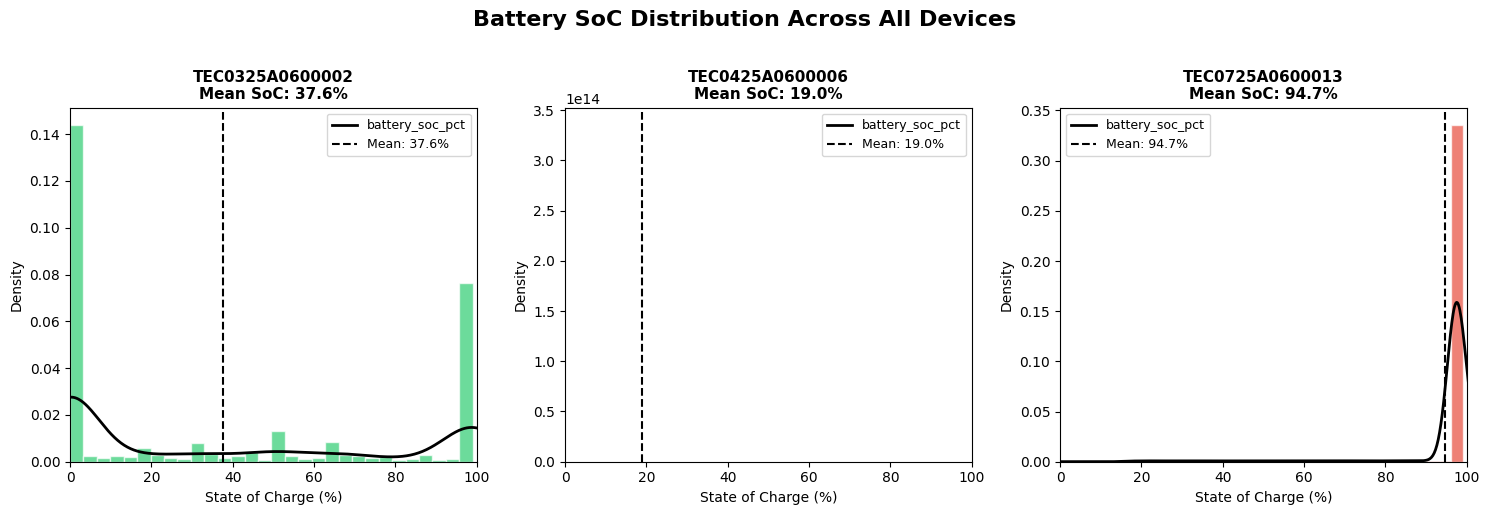

✅ Chart 1 saved!


In [13]:
# ── Chart 1: SoC Distribution (Histogram + KDE) ───────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

devices = df['device_id'].unique()
colors = ['#2ecc71', '#3498db', '#e74c3c']

for idx, (device, color) in enumerate(zip(devices, colors)):
    device_df = df[df['device_id'] == device]
    
    axes[idx].hist(
        device_df['battery_soc_pct'], 
        bins=30, 
        color=color, 
        alpha=0.7,
        edgecolor='white',
        density=True
    )
    
    # Add KDE line
    device_df['battery_soc_pct'].plot.kde(
        ax=axes[idx], 
        color='black', 
        linewidth=2
    )
    
    axes[idx].set_title(
        f'{device}\nMean SoC: {device_df["battery_soc_pct"].mean():.1f}%', 
        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('State of Charge (%)', fontsize=10)
    axes[idx].set_ylabel('Density', fontsize=10)
    
    # Force x axis within valid range
    axes[idx].set_xlim(0, 100)
    
    # Mean line
    axes[idx].axvline(
        device_df['battery_soc_pct'].mean(), 
        color='black', 
        linestyle='--', 
        linewidth=1.5,
        label=f'Mean: {device_df["battery_soc_pct"].mean():.1f}%'
    )
    axes[idx].legend(fontsize=9)

plt.suptitle('Battery SoC Distribution Across All Devices', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../outputs/eda_charts/chart1_soc_distribution.png', 
            bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

In [14]:
# Investigate each device's behaviour
print("📊 Battery State breakdown per device:")
state_breakdown = pd.crosstab(
    df['device_id'], 
    df['battery_state'],
    normalize='index'
) * 100
print(state_breakdown.round(2).to_string())

print("\n📊 SoC statistics per device:")
print(df.groupby('device_id')['battery_soc_pct'].agg([
    'mean', 'std', 'min', 'max', 'median'
]).round(2).to_string())

print("\n📊 Device status breakdown per device:")
status_breakdown = pd.crosstab(
    df['device_id'],
    df['device_status'],
    normalize='index'
) * 100
print(status_breakdown.round(2).to_string())

📊 Battery State breakdown per device:
battery_state    Charging  Discharging     Idle
device_id                                      
TEC0325A0600002    0.1000      21.5400  78.3600
TEC0425A0600006    0.0000       0.0000 100.0000
TEC0725A0600013    7.1400       0.0000  92.8600

📊 SoC statistics per device:
                   mean     std     min     max  median
device_id                                              
TEC0325A0600002 37.5500 42.2000  0.0000 99.0000 15.0000
TEC0425A0600006 19.0000  0.0000 19.0000 19.0000 19.0000
TEC0725A0600013 94.7200 12.2300 16.0000 99.0000 97.0000

📊 Device status breakdown per device:
device_status    Active  Inactive
device_id                        
TEC0325A0600002 21.6400   78.3600
TEC0425A0600006  0.0000  100.0000
TEC0725A0600013  7.1400   92.8600


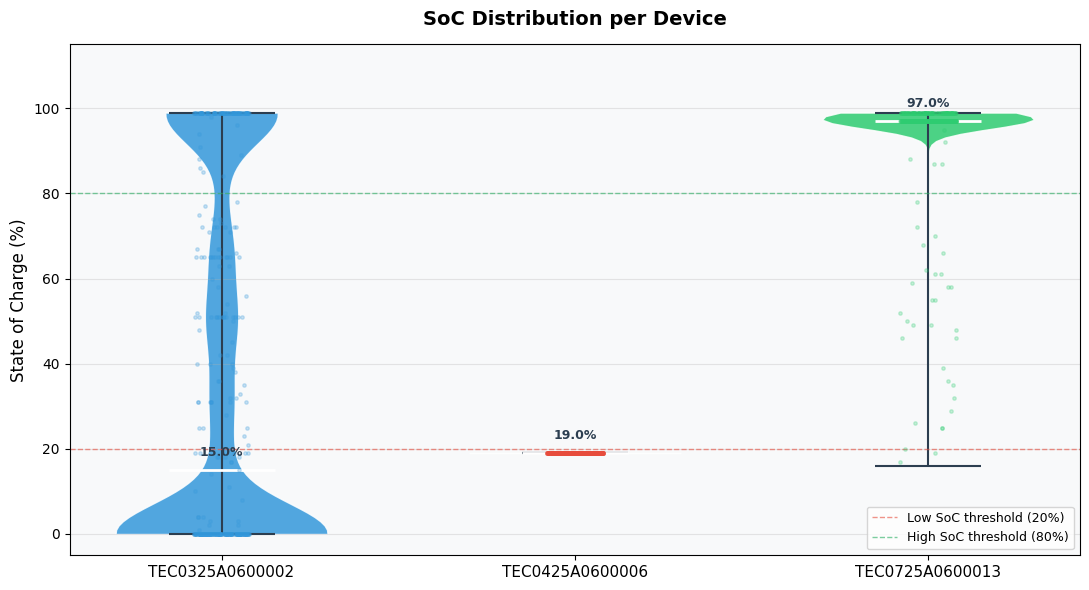

✅ Saved → outputs/eda_charts/soc_violin_per_device.png


In [15]:
# ── SoC Distribution — Violin Plot per Device ────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

devices_sorted = sorted(df['device_id'].unique())
COLOURS = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

# Build per-device data list for violin
data_per_device = [
    df.loc[df['device_id'] == dev, 'battery_soc_pct'].dropna().values
    for dev in devices_sorted
]

parts = ax.violinplot(
    data_per_device,
    positions=range(len(devices_sorted)),
    showmedians=True,
    showextrema=True,
    widths=0.6,
)

# Colour each violin body
for i, (body, col) in enumerate(zip(parts['bodies'], COLOURS)):
    body.set_facecolor(col)
    body.set_edgecolor('white')
    body.set_alpha(0.85)

parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)
parts['cmins'].set_color('#2c3e50')
parts['cmaxes'].set_color('#2c3e50')
parts['cbars'].set_color('#2c3e50')

# Overlay individual quartile stats as text
for i, (dev, data) in enumerate(zip(devices_sorted, data_per_device)):
    q1, med, q3 = float(np.percentile(data, 25)), float(np.median(data)), float(np.percentile(data, 75))
    ax.text(i, med + 2.5, f'{med:.1f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#2c3e50')

# Scatter jitter overlay for feel of data density
rng = np.random.default_rng(42)
for i, (data, col) in enumerate(zip(data_per_device, COLOURS)):
    jitter = rng.uniform(-0.08, 0.08, size=min(len(data), 400))
    sample = rng.choice(data, size=min(len(data), 400), replace=False)
    ax.scatter(i + jitter, sample, s=6, alpha=0.25, color=col, zorder=3)

ax.set_xticks(range(len(devices_sorted)))
ax.set_xticklabels(devices_sorted, fontsize=11)
ax.set_ylabel('State of Charge (%)', fontsize=12)
ax.set_title('SoC Distribution per Device', fontsize=14, fontweight='bold', pad=14)
ax.set_ylim(-5, 115)
ax.axhline(20,  color='#e74c3c', linewidth=1, linestyle='--', alpha=0.6, label='Low SoC threshold (20%)')
ax.axhline(80,  color='#27ae60', linewidth=1, linestyle='--', alpha=0.6, label='High SoC threshold (80%)')
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('../outputs/eda_charts/soc_violin_per_device.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → outputs/eda_charts/soc_violin_per_device.png")


In [16]:
# ============================================================
# KEY FINDING - Device Profile Classification
# ============================================================

print("=" * 60)
print("🔍 KEY FINDINGS - DEVICE PROFILES")
print("=" * 60)

print("""
TEC0325A0600002 → ACTIVE VEHICLE
  ✅ Only vehicle actually being driven
  ✅ Full charge/discharge cycles observed
  ✅ SoC range: 0-99%
  ✅ Active 21.6% of monitoring period

TEC0425A0600006 → ANOMALOUS - POSSIBLE SENSOR FAULT
  ❌ Never active, never driven
  ❌ SoC stuck at exactly 19% for entire period
  ❌ Zero standard deviation in SoC
  ❌ Likely decommissioned or sensor malfunction
  ⚠️  Carbon credits: ZERO - no energy displacement

TEC0725A0600013 → RESERVE/BACKUP VEHICLE  
  ⚠️  Only charges, never discharges
  ⚠️  SoC always 90-99% - kept on standby
  ⚠️  No driving activity detected
  ⚠️  Carbon credits: ZERO - no distance travelled
""")

print("=" * 60)
print("💡 RECOMMENDATION:")
print("   Only TEC0325A0600002 should generate carbon credits")
print("   TEC0425A0600006 requires immediate hardware inspection")
print("=" * 60)

🔍 KEY FINDINGS - DEVICE PROFILES

TEC0325A0600002 → ACTIVE VEHICLE
  ✅ Only vehicle actually being driven
  ✅ Full charge/discharge cycles observed
  ✅ SoC range: 0-99%
  ✅ Active 21.6% of monitoring period

TEC0425A0600006 → ANOMALOUS - POSSIBLE SENSOR FAULT
  ❌ Never active, never driven
  ❌ SoC stuck at exactly 19% for entire period
  ❌ Zero standard deviation in SoC
  ❌ Likely decommissioned or sensor malfunction
  ⚠️  Carbon credits: ZERO - no energy displacement

TEC0725A0600013 → RESERVE/BACKUP VEHICLE  
  ⚠️  Only charges, never discharges
  ⚠️  SoC always 90-99% - kept on standby
  ⚠️  No driving activity detected
  ⚠️  Carbon credits: ZERO - no distance travelled

💡 RECOMMENDATION:
   Only TEC0325A0600002 should generate carbon credits
   TEC0425A0600006 requires immediate hardware inspection


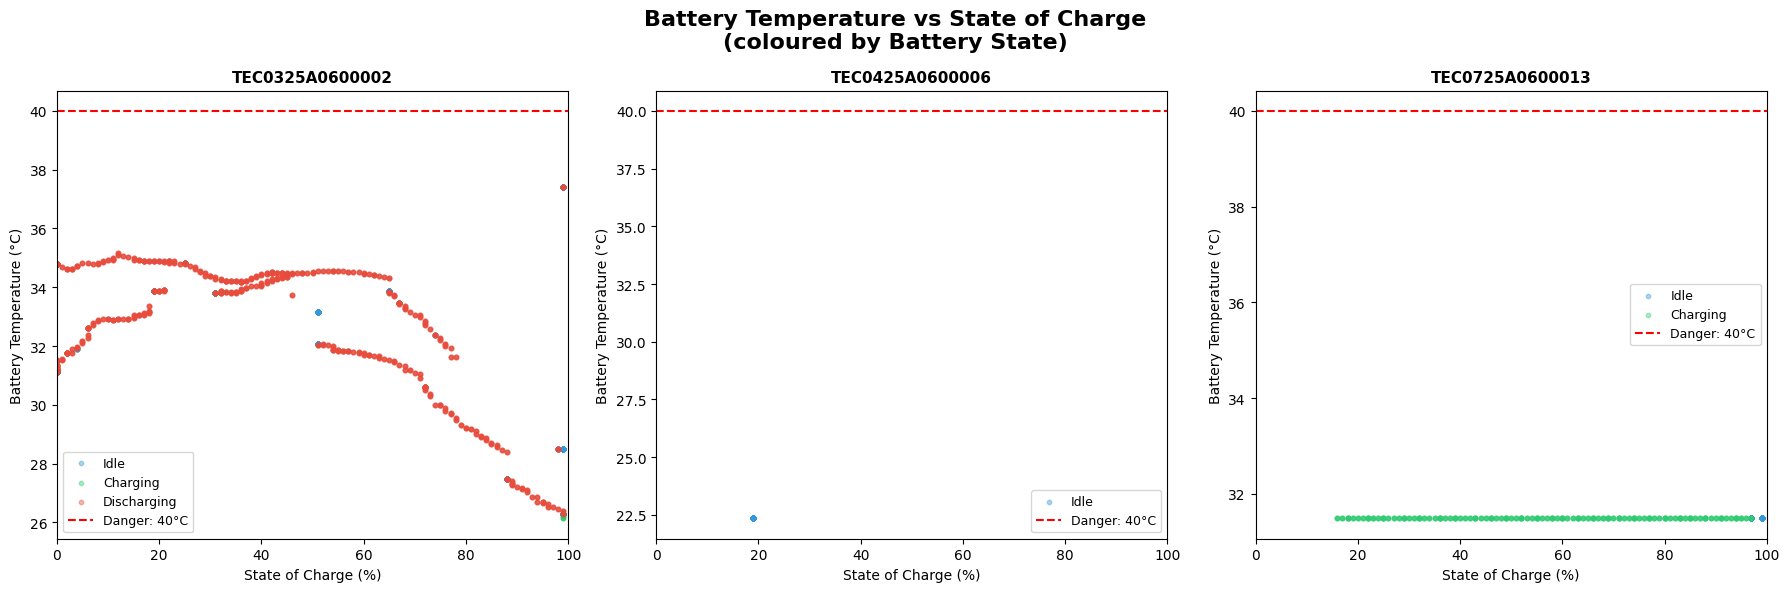

✅ Chart 2 saved!


In [17]:
# ── Chart 2: Battery Temperature vs SoC Scatter ───────────
# --- FIX CORE DATA ISSUES ---

# 1. Sort properly (CRITICAL)
df['ts'] = pd.to_datetime(df['ts'])
df = df.sort_values(['device_id', 'ts'])
df = df.sort_values(['device_id', 'ts'])

# 2. Drop garbage rows
df = df.dropna(subset=['battery_soc_pct', 'battery_temp_c', 'battery_state'])

# 3. Clamp valid ranges (removes weird spikes)
df = df[
    (df['battery_soc_pct'] >= 0) & (df['battery_soc_pct'] <= 100) &
    (df['battery_temp_c'] >= 15) & (df['battery_temp_c'] <= 60)
]



# 5. Ensure minimum data points per device
df = df.groupby('device_id').filter(lambda x: len(x) > 20)
devices = df['device_id'].unique()
n = len(devices)

fig, axes = plt.subplots(1, n, figsize=(6*n, 6))

# Handle single device edge case
if n == 1:
    axes = [axes]

devices = df['device_id'].unique()

# Color map for battery states
state_colors = {
    'Idle': '#3498db',
    'Charging': '#2ecc71', 
    'Discharging': '#e74c3c'
}

for idx, device in enumerate(devices):
    device_df = df[df['device_id'] == device]
    
    for state, color in state_colors.items():
        state_df = device_df[device_df['battery_state'] == state]
        if len(state_df) > 0:
            axes[idx].scatter(
                state_df['battery_soc_pct'],
                state_df['battery_temp_c'],
                c=color,
                label=state,
                alpha=0.4,
                s=10
            )
    
    axes[idx].set_title(
        f'{device}', 
        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('State of Charge (%)', fontsize=10)
    axes[idx].set_ylabel('Battery Temperature (°C)', fontsize=10)
    axes[idx].set_xlim(0, 100)
    axes[idx].legend(fontsize=9)
    
    # Add danger line at 40°C
    axes[idx].axhline(
        y=40, 
        color='red', 
        linestyle='--', 
        linewidth=1.5,
        label='Danger: 40°C'
    )
    axes[idx].legend(fontsize=9)

plt.suptitle(
    'Battery Temperature vs State of Charge\n(coloured by Battery State)', 
    fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/eda_charts/chart2_temp_vs_soc.png', 
            bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

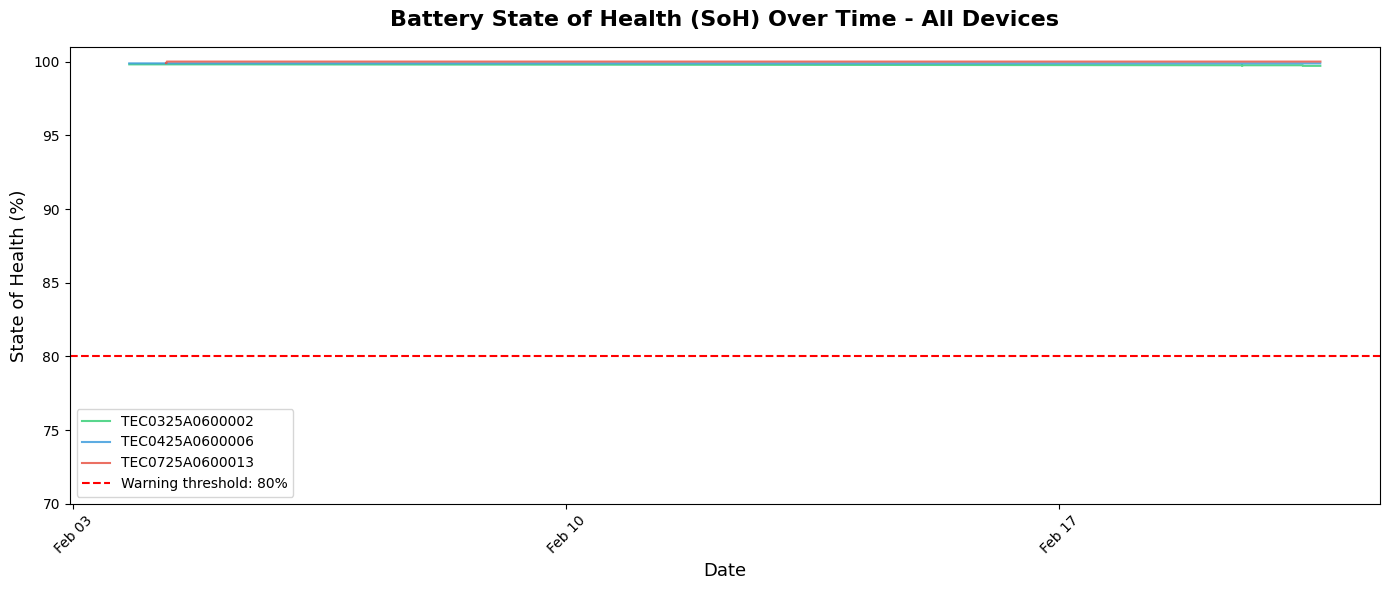

✅ Chart 3 saved!


In [18]:
# ── Chart 3: Per-device SoH Over Time ─────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

devices = df['device_id'].unique()
colors = ['#2ecc71', '#3498db', '#e74c3c']

for device, color in zip(devices, colors):
    device_df = df[df['device_id'] == device].sort_values('ts')
    
    ax.plot(
        device_df['ts'],
        device_df['battery_soh_pct'],
        color=color,
        linewidth=1.5,
        label=device,
        alpha=0.8
    )

# Add warning threshold line
ax.axhline(
    y=80, 
    color='red', 
    linestyle='--', 
    linewidth=1.5,
    label='Warning threshold: 80%'
)

ax.set_title(
    'Battery State of Health (SoH) Over Time - All Devices',
    fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('State of Health (%)', fontsize=13)
ax.set_ylim(70, 101)
ax.legend(fontsize=10)

# Format x axis dates
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../outputs/eda_charts/chart3_soh_over_time.png',
            bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

In [19]:
print("📊 SoH statistics per device:")
print(df.groupby('device_id')['battery_soh_pct'].agg([
    'mean', 'std', 'min', 'max'
]).round(4).to_string())

📊 SoH statistics per device:
                   mean    std     min      max
device_id                                      
TEC0325A0600002 99.7753 0.0354 99.7100  99.8100
TEC0425A0600006 99.8800 0.0000 99.8800  99.8800
TEC0725A0600013 99.9995 0.0067 99.9000 100.0000


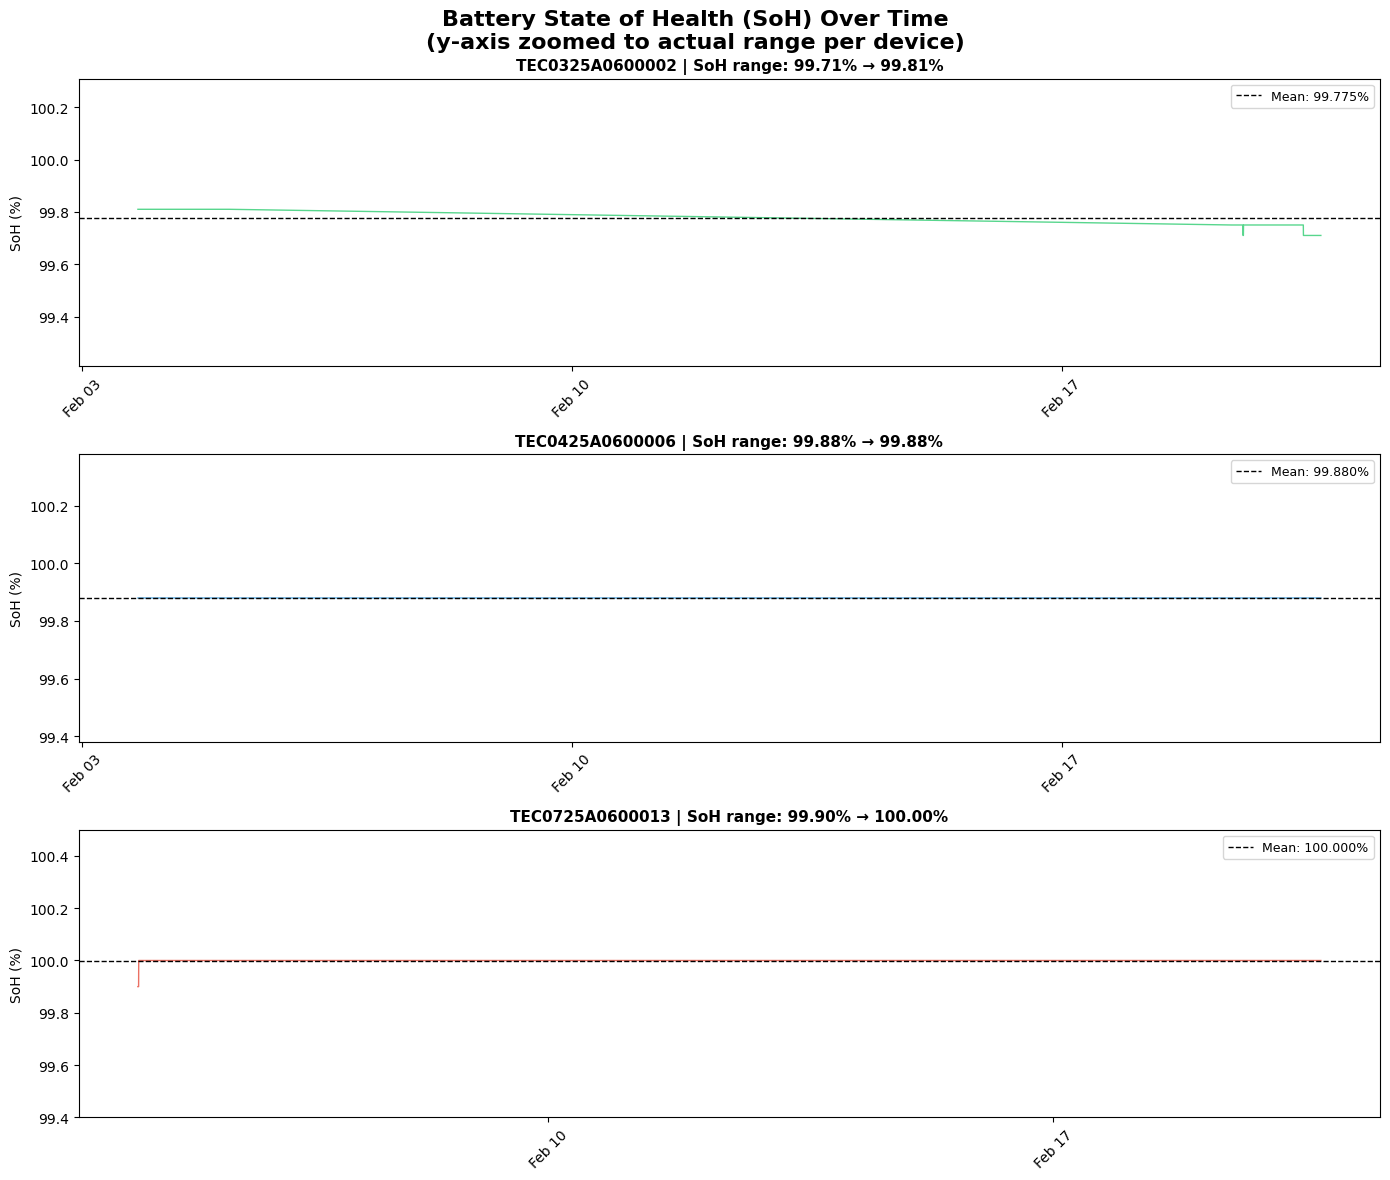

✅ Chart 3.5 saved!


In [20]:
# ── Chart 3 Improved: SoH Over Time (zoomed) ──────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

devices = df['device_id'].unique()
colors = ['#2ecc71', '#3498db', '#e74c3c']

for idx, (device, color) in enumerate(zip(devices, colors)):
    device_df = df[df['device_id'] == device].sort_values('ts')
    
    axes[idx].plot(
        device_df['ts'],
        device_df['battery_soh_pct'],
        color=color,
        linewidth=1,
        alpha=0.8
    )
    
    # Zoom y axis to actual data range
    min_soh = device_df['battery_soh_pct'].min()
    max_soh = device_df['battery_soh_pct'].max()
    padding = 0.5
    axes[idx].set_ylim(min_soh - padding, max_soh + padding)
    
    axes[idx].set_title(
        f'{device} | SoH range: {min_soh:.2f}% → {max_soh:.2f}%',
        fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('SoH (%)', fontsize=10)
    
    # Add mean line
    mean_soh = device_df['battery_soh_pct'].mean()
    axes[idx].axhline(
        y=mean_soh,
        color='black',
        linestyle='--',
        linewidth=1,
        label=f'Mean: {mean_soh:.3f}%'
    )
    axes[idx].legend(fontsize=9)
    
    # Format dates
    import matplotlib.dates as mdates
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axes[idx].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle(
    'Battery State of Health (SoH) Over Time\n(y-axis zoomed to actual range per device)',
    fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/eda_charts/chart3.5_soh_over_time.png',
            bbox_inches='tight')
plt.show()
print("✅ Chart 3.5 saved!")

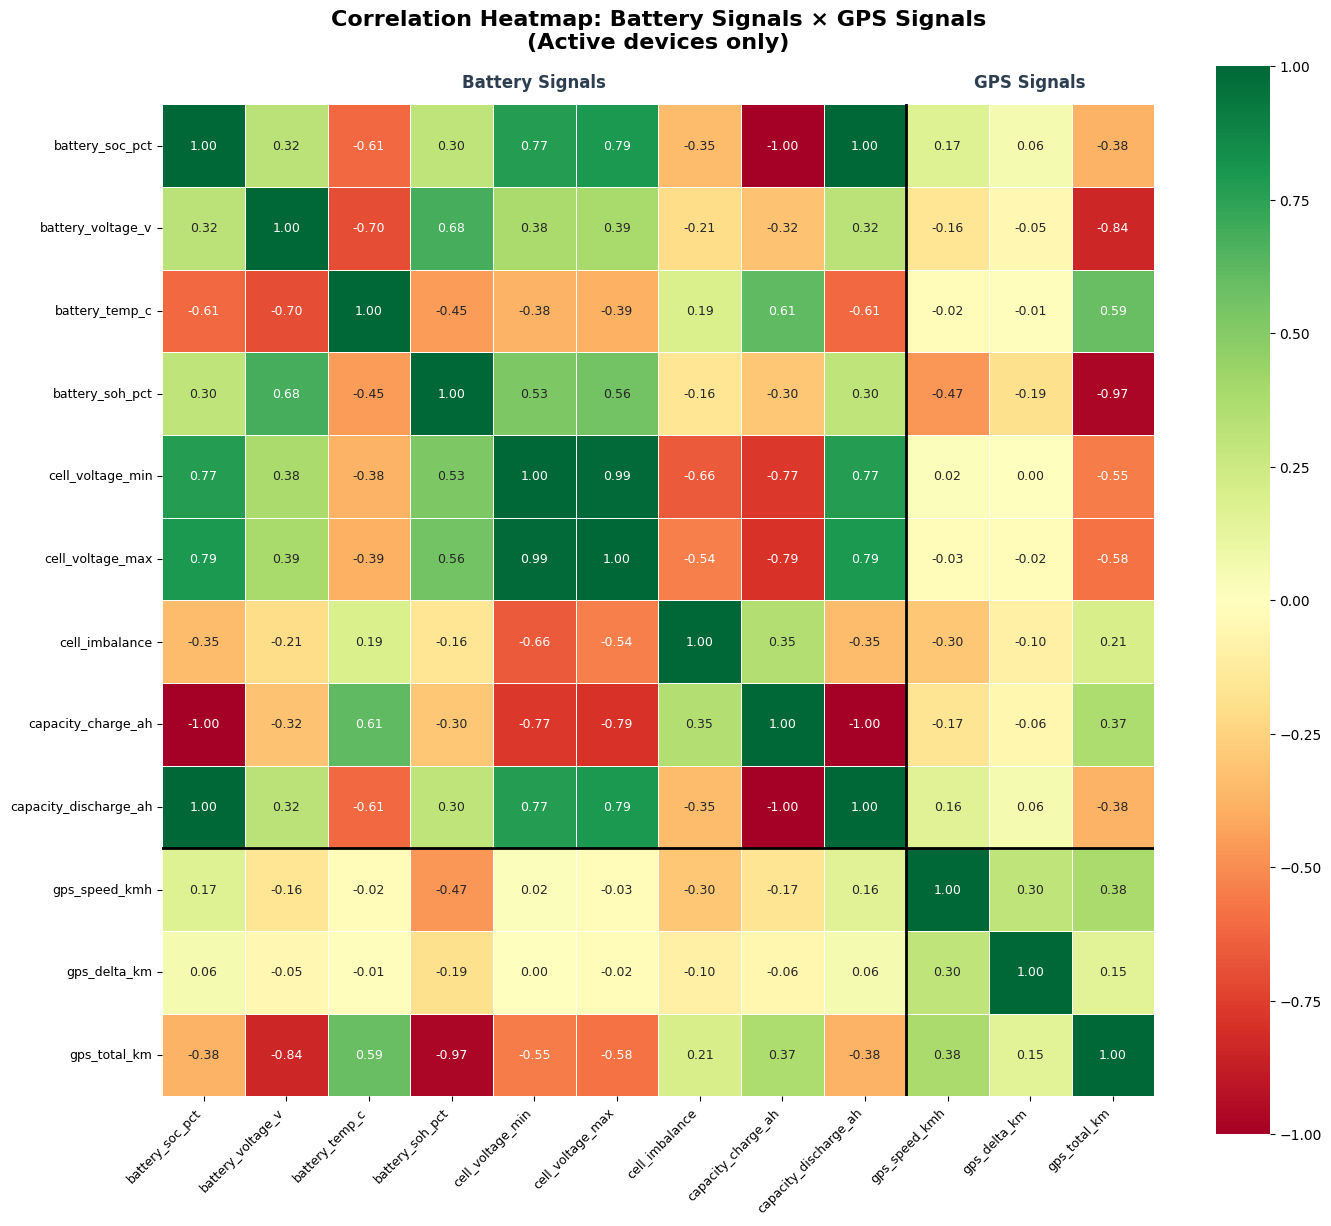

✅ Chart 5 saved!


In [21]:
# ── Define signal groups ──────────────────────────────────────────────
battery_cols = [
    'battery_soc_pct', 'battery_voltage_v', 'battery_temp_c',
    'battery_soh_pct', 'cell_voltage_min', 'cell_voltage_max',
    'cell_imbalance', 'capacity_charge_ah', 'capacity_discharge_ah',
]
gps_cols = ['gps_speed_kmh', 'gps_delta_km', 'gps_total_km']

all_signal_cols = battery_cols + gps_cols

# Filter to active devices only and compute correlation matrix
df_active = df[df['device_status'] == 'Active']
corr_matrix = df_active[all_signal_cols].corr().round(2)

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)

# Draw divider line between battery and gps sections
ax.axhline(y=len(battery_cols), color='black', linewidth=2)
ax.axvline(x=len(battery_cols), color='black', linewidth=2)

# Add section labels
ax.text(
    len(battery_cols) / 2, -0.2,
    'Battery Signals',
    ha='center', fontsize=12,
    fontweight='bold', color='#2c3e50'
)
ax.text(
    len(battery_cols) + len(gps_cols) / 2, -0.2,
    'GPS Signals',
    ha='center', fontsize=12,
    fontweight='bold', color='#2c3e50'
)

ax.set_title(
    'Correlation Heatmap: Battery Signals × GPS Signals\n(Active devices only)',
    fontsize=16,
    fontweight='bold',
    pad=40        # ← increased padding
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

# Add extra space at top
plt.subplots_adjust(top=1)

plt.savefig(
    '../outputs/eda_charts/chart5_correlation_heatmap.png',
    bbox_inches='tight'
)
plt.show()
print("✅ Chart 5 saved!")


TEC0325A0600002 combined state counts:
combined_state
Inactive    5978
Active      1643
Charging       8
   Total segments: 29
   Charging segments: 1
   → Feb 04 04:54 to Feb 04 04:58 (4.0 min)

TEC0425A0600006 combined state counts:
combined_state
Inactive    7629
   Total segments: 1
   Charging segments: 0

TEC0725A0600013 combined state counts:
combined_state
Inactive    5712
Charging     439
   Total segments: 3
   Charging segments: 1
   → Feb 04 07:48 to Feb 04 11:28 (219.5 min)


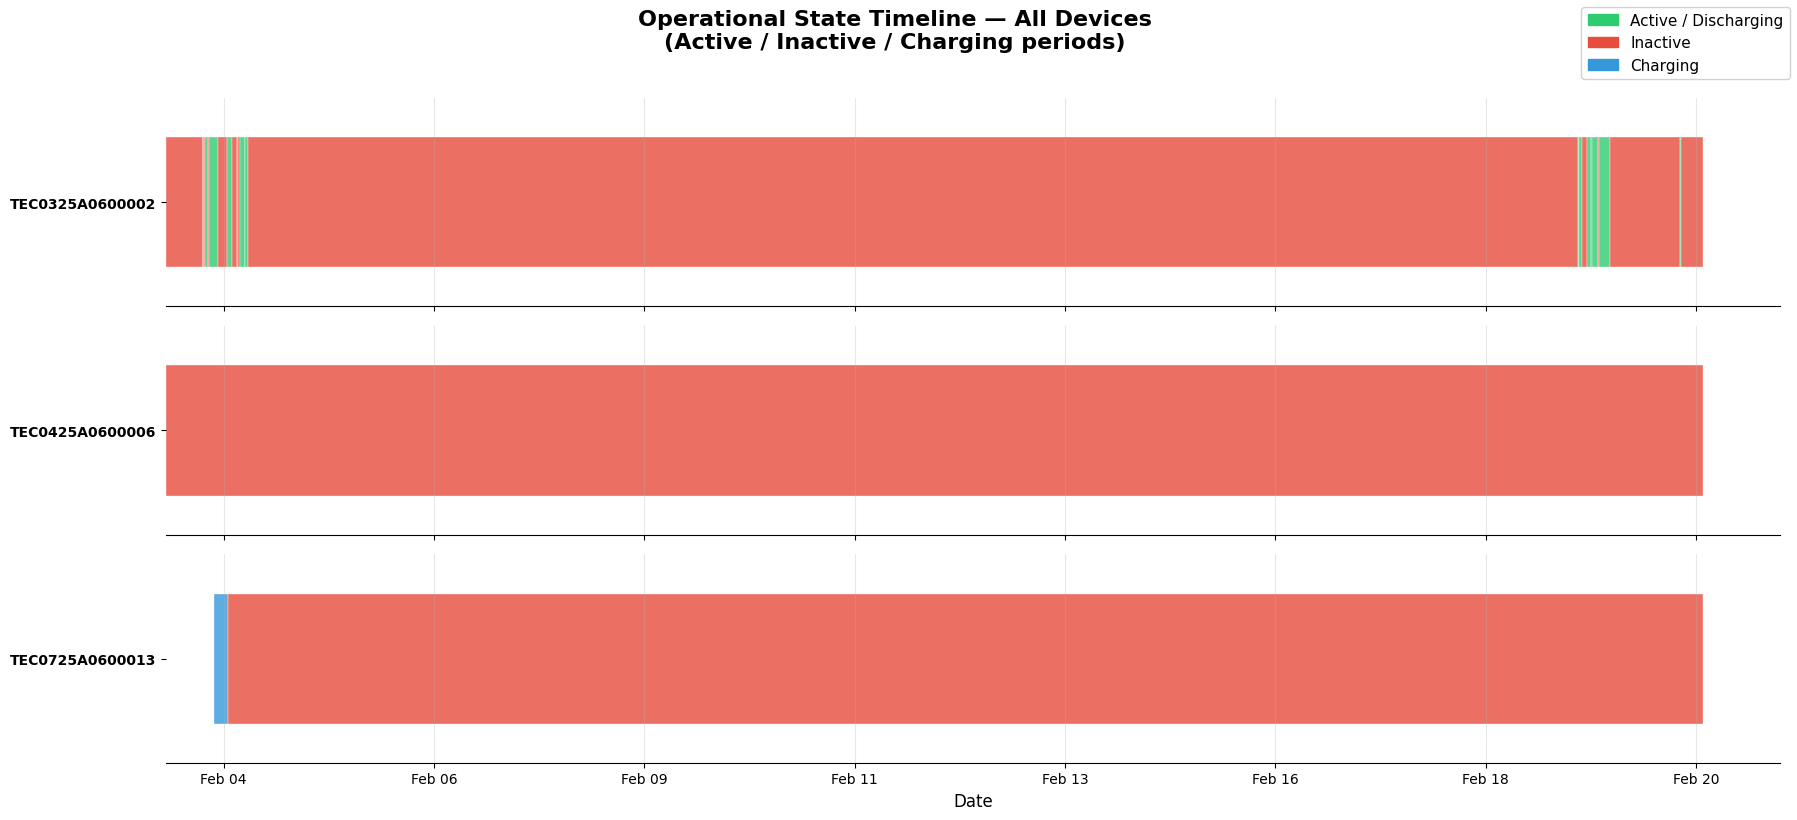


✅ Chart 6 saved!


In [22]:
# ── Chart 6 Fixed: Gantt-style Operational Timeline ───────
import matplotlib.patches as mpatches

sample_devices = df['device_id'].unique()[:3]

fig, axes = plt.subplots(
    len(sample_devices), 1,
    figsize=(18, 8),
    sharex=True
)

def get_combined_state(device_status, battery_state):
    """
    Priority: Charging > Active/Discharging > Inactive
    Battery state takes priority over device status
    """
    battery_state = str(battery_state)
    device_status = str(device_status)
    
    if battery_state == 'Charging':
        return 'Charging'
    elif battery_state == 'Discharging' or device_status == 'Active':
        return 'Active'
    else:
        return 'Inactive'

state_colors = {
    'Active':   '#2ecc71',
    'Inactive': '#e74c3c',
    'Charging': '#3498db'
}

for idx, device in enumerate(sample_devices):
    device_df = df[df['device_id'] == device].sort_values('ts').copy()
    ax        = axes[idx]

    # Apply combined state with correct priority
    device_df['combined_state'] = device_df.apply(
        lambda row: get_combined_state(
            row['device_status'],
            row['battery_state']
        ), axis=1
    )

    # Debug — confirm charging rows exist
    print(f"\n{device} combined state counts:")
    print(device_df['combined_state'].value_counts().to_string())

    # Build segments
    segments   = []
    start_ts   = device_df.iloc[0]['ts']
    curr_state = device_df.iloc[0]['combined_state']

    for _, row in device_df.iterrows():
        if row['combined_state'] != curr_state:
            segments.append({
                'start': start_ts,
                'end':   row['ts'],
                'state': curr_state
            })
            start_ts   = row['ts']
            curr_state = row['combined_state']

    # Add last segment
    segments.append({
        'start': start_ts,
        'end':   device_df.iloc[-1]['ts'],
        'state': curr_state
    })

    print(f"   Total segments: {len(segments)}")
    charging_segs = [s for s in segments if s['state'] == 'Charging']
    print(f"   Charging segments: {len(charging_segs)}")
    for s in charging_segs:
        duration = (s['end'] - s['start']).total_seconds() / 60
        print(f"   → {s['start'].strftime('%b %d %H:%M')} "
              f"to {s['end'].strftime('%b %d %H:%M')} "
              f"({duration:.1f} min)")

    # Plot segments
    for seg in segments:
        start = seg['start'].timestamp()
        end   = seg['end'].timestamp()
        width = end - start
        color = state_colors[seg['state']]

        ax.barh(
            y=0,
            width=width,
            left=start,
            height=0.5,
            color=color,
            alpha=0.8,
            edgecolor='white',
            linewidth=0.3
        )

    # Format x axis
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda x, p: pd.Timestamp(x, unit='s').strftime('%b %d')
        )
    )

    ax.set_yticks([0])
    ax.set_yticklabels([device], fontsize=10, fontweight='bold')
    ax.set_ylim(-0.4, 0.4)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

# Legend
patches = [
    mpatches.Patch(color='#2ecc71', label='Active / Discharging'),
    mpatches.Patch(color='#e74c3c', label='Inactive'),
    mpatches.Patch(color='#3498db', label='Charging')
]
fig.legend(
    handles=patches,
    loc='upper right',
    fontsize=11,
    framealpha=0.9
)

plt.suptitle(
    'Operational State Timeline — All Devices\n(Active / Inactive / Charging periods)',
    fontsize=16,
    fontweight='bold',
    y=1.02
)
plt.xlabel('Date', fontsize=12)
plt.tight_layout()
plt.savefig(
    '../outputs/eda_charts/chart6_operational_timeline.png',
    bbox_inches='tight'
)
plt.show()
print("\n✅ Chart 6 saved!")

In [23]:
# ============================================================
# EDA Charts HTML Report
# ============================================================

import base64
from io import BytesIO

def img_to_base64(img_path):
    """Convert saved PNG to base64 for HTML embedding"""
    with open(img_path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')

# Load all saved charts
charts = {
    'chart1': img_to_base64('../outputs/eda_charts/chart1_soc_distribution.png'),
    'chart2': img_to_base64('../outputs/eda_charts/chart2_temp_vs_soc.png'),
    'chart3': img_to_base64('../outputs/eda_charts/chart3_soh_over_time.png'),
    'chart5': img_to_base64('../outputs/eda_charts/chart5_correlation_heatmap.png'),
    'chart6': img_to_base64('../outputs/eda_charts/chart6_operational_timeline.png'),
}

date_from = df['ts'].min().strftime('%b %d, %Y')
date_to   = df['ts'].max().strftime('%b %d, %Y')

html = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>RenewCred EV Telemetry - EDA Charts</title>
    <style>
        * { box-sizing: border-box; margin: 0; padding: 0; }
        body {
            font-family: Arial, sans-serif;
            background: #f5f6fa;
            color: #2c3e50;
            padding: 20px;
        }
        .header {
            background: linear-gradient(135deg, #2c3e50, #3498db);
            color: white;
            padding: 30px;
            border-radius: 10px;
            margin-bottom: 25px;
        }
        .header h1 { font-size: 24px; margin-bottom: 5px; }
        .header p  { opacity: 0.8; font-size: 14px; }

        /* Navigation tabs */
        .tabs {
            display: flex;
            gap: 8px;
            margin-bottom: 20px;
            flex-wrap: wrap;
        }
        .tab {
            padding: 8px 16px;
            border-radius: 20px;
            border: 2px solid #3498db;
            background: white;
            color: #3498db;
            cursor: pointer;
            font-size: 12px;
            font-weight: bold;
            transition: all 0.2s;
        }
        .tab:hover, .tab.active {
            background: #3498db;
            color: white;
        }

        /* Chart cards */
        .chart-section { display: none; }
        .chart-section.active { display: block; }

        .card {
            background: white;
            border-radius: 10px;
            padding: 25px;
            margin-bottom: 20px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.08);
        }
        .card h2 {
            font-size: 18px;
            color: #2c3e50;
            margin-bottom: 8px;
            border-bottom: 2px solid #3498db;
            padding-bottom: 8px;
        }
        .card p {
            font-size: 13px;
            color: #7f8c8d;
            margin-bottom: 15px;
            line-height: 1.6;
        }
        .chart-img {
            width: 100%;
            border-radius: 8px;
            border: 1px solid #ecf0f1;
        }

        /* GPS map link card */
        .map-card {
            background: white;
            border-radius: 10px;
            padding: 25px;
            margin-bottom: 20px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.08);
            text-align: center;
        }
        .map-card h2 {
            font-size: 18px;
            color: #2c3e50;
            margin-bottom: 8px;
            border-bottom: 2px solid #3498db;
            padding-bottom: 8px;
            text-align: left;
        }
        .map-card p {
            font-size: 13px;
            color: #7f8c8d;
            margin-bottom: 20px;
            text-align: left;
            line-height: 1.6;
        }
        .map-btn {
            display: inline-block;
            padding: 12px 30px;
            background: #3498db;
            color: white;
            border-radius: 25px;
            text-decoration: none;
            font-weight: bold;
            font-size: 14px;
            transition: background 0.2s;
        }
        .map-btn:hover { background: #2980b9; }

        /* Summary grid */
        .summary-grid {
            display: grid;
            grid-template-columns: repeat(3, 1fr);
            gap: 15px;
            margin-bottom: 20px;
        }
        .summary-card {
            background: white;
            border-radius: 10px;
            padding: 20px;
            text-align: center;
            box-shadow: 0 2px 10px rgba(0,0,0,0.08);
        }
        .summary-card .number {
            font-size: 28px;
            font-weight: bold;
            color: #3498db;
        }
        .summary-card .label {
            font-size: 12px;
            color: #7f8c8d;
            margin-top: 5px;
        }

        .footer {
            text-align: center;
            color: #7f8c8d;
            font-size: 12px;
            margin-top: 20px;
        }
    </style>
</head>
<body>
"""

html += f"""
    <div class="header">
        <h1>📊 RenewCred EV Telemetry — EDA Charts</h1>
        <p>Exploratory Data Analysis · {date_from} → {date_to} · 
           {len(df):,} readings · {df['device_id'].nunique()} devices</p>
    </div>

    <!-- Navigation Tabs -->
    <div class="tabs">
        <div class="tab active" onclick="showTab('overview')">
            📋 Overview
        </div>
        <div class="tab" onclick="showTab('chart1')">
            1. SoC Distribution
        </div>
        <div class="tab" onclick="showTab('chart2')">
            2. Temp vs SoC
        </div>
        <div class="tab" onclick="showTab('chart3')">
            3. SoH Over Time
        </div>
        <div class="tab" onclick="showTab('chart4')">
            4. GPS Heatmap
        </div>
        <div class="tab" onclick="showTab('chart5')">
            5. Correlation
        </div>
        <div class="tab" onclick="showTab('chart6')">
            6. Timeline
        </div>
    </div>

    <!-- Overview Tab -->
    <div id="overview" class="chart-section active">

        <div class="summary-grid">
            <div class="summary-card">
                <div class="number">{len(df):,}</div>
                <div class="label">Total Readings</div>
            </div>
            <div class="summary-card">
                <div class="number">{df['device_id'].nunique()}</div>
                <div class="label">Unique Devices</div>
            </div>
            <div class="summary-card">
                <div class="number">6</div>
                <div class="label">EDA Charts</div>
            </div>
        </div>

        <div class="card">
            <h2>📌 Key Findings</h2>
            <p>
                <b>TEC0325A0600002</b> — Only actively driven vehicle. 
                SoC ranges 0–99%, discharging 21.5% of time. 
                Travelled 807.82 km over 17 days.<br><br>
                <b>TEC0425A0600006</b> — Anomalous device. 
                SoC stuck at exactly 19% with zero standard deviation. 
                Never active, never driven. Possible sensor fault 
                or decommissioned vehicle.<br><br>
                <b>TEC0725A0600013</b> — Reserve/standby vehicle. 
                Only charges, never discharges. 
                SoC consistently 90–99%. No distance travelled.
            </p>
        </div>

        <div class="card">
            <h2>🗂️ All Charts</h2>
            <p>Click any tab above to view individual charts. 
               Chart 4 (GPS Heatmap) opens as an interactive 
               Folium map.</p>
            <img class="chart-img" 
                 src="data:image/png;base64,{charts['chart1']}"
                 alt="SoC Distribution" 
                 style="margin-bottom:15px;"/>
            <img class="chart-img" 
                 src="data:image/png;base64,{charts['chart2']}"
                 alt="Temp vs SoC"
                 style="margin-bottom:15px;"/>
            <img class="chart-img" 
                 src="data:image/png;base64,{charts['chart3']}"
                 alt="SoH Over Time"
                 style="margin-bottom:15px;"/>
            <img class="chart-img" 
                 src="data:image/png;base64,{charts['chart5']}"
                 alt="Correlation Heatmap"
                 style="margin-bottom:15px;"/>
            <img class="chart-img" 
                 src="data:image/png;base64,{charts['chart6']}"
                 alt="Operational Timeline"/>
        </div>
    </div>

    <!-- Chart 1 Tab -->
    <div id="chart1" class="chart-section">
        <div class="card">
            <h2>1. SoC Distribution Across All Devices</h2>
            <p>
                Histogram with KDE showing state of charge distribution 
                per device. TEC0325A0600002 shows a bimodal distribution 
                (peaks at 0–20% and 80–100%) indicating active 
                charge/discharge cycles. TEC0425A0600006 shows a single 
                spike at 19% confirming sensor fault. 
                TEC0725A0600013 clusters near 90–100% 
                indicating standby mode.
            </p>
            <img class="chart-img" 
                 src="data:image/png;base64,{charts['chart1']}"
                 alt="SoC Distribution"/>
        </div>
    </div>

    <!-- Chart 2 Tab -->
    <div id="chart2" class="chart-section">
        <div class="card">
            <h2>2. Battery Temperature vs SoC (coloured by Battery State)</h2>
            <p>
                Scatter plot showing relationship between battery 
                temperature and state of charge, coloured by 
                battery state (Idle/Charging/Discharging). 
                TEC0325A0600002 shows temperature rising 26°C → 34°C 
                during discharge. Red dashed line marks 40°C danger 
                threshold — all readings safely below.
            </p>
            <img class="chart-img" 
                 src="data:image/png;base64,{charts['chart2']}"
                 alt="Temp vs SoC"/>
        </div>
    </div>

    <!-- Chart 3 Tab -->
    <div id="chart3" class="chart-section">
        <div class="card">
            <h2>3. Per-Device SoH Over Time</h2>
            <p>
                Multi-line time series showing battery state of health 
                per device. All devices show SoH near 100% — expected 
                over a 17-day window as SoH degrades over months/years 
                of charge cycles, not days. Y-axis zoomed to actual 
                range per device to show micro-variations.
            </p>
            <img class="chart-img" 
                 src="data:image/png;base64,{charts['chart3']}"
                 alt="SoH Over Time"/>
        </div>
    </div>

    <!-- Chart 4 Tab - GPS Map -->
    <div id="chart4" class="chart-section">
        <div class="map-card">
            <h2>4. GPS Heatmap of Vehicle Locations</h2>
            <p>
                Interactive Folium map showing GPS heatmap of all 
                vehicle locations. TEC0325A0600002 and TEC0725A0600013 
                operate in the Coimbatore/Tamil Nadu region. 
                TEC0425A0600006 is located in Pune, Maharashtra 
                with minimal GPS movement confirming inactivity.
                Click on vehicle markers to view live stats including
                battery health, SoC, temperature and distance travelled.
            </p>
            <a class="map-btn" href="gps_map.html" target="_blank">
                🗺️ Open Interactive GPS Map
            </a>
        </div>
    </div>

    <!-- Chart 5 Tab -->
    <div id="chart5" class="chart-section">
        <div class="card">
            <h2>5. Correlation Heatmap: Battery Signals × GPS Signals</h2>
            <p>
                Correlation matrix between battery signals and GPS 
                signals. Computed on active devices only 
                (TEC0425A0600006 excluded due to zero variance). 
                Strong positive correlation observed between 
                gps_total_km and capacity_discharge_ah confirming 
                energy consumption tracks distance travelled.
            </p>
            <img class="chart-img" 
                 src="data:image/png;base64,{charts['chart5']}"
                 alt="Correlation Heatmap"/>
        </div>
    </div>

    <!-- Chart 6 Tab -->
    <div id="chart6" class="chart-section">
        <div class="card">
            <h2>6. Operational State Timeline</h2>
            <p>
                Gantt-style chart showing Active (green), 
                Inactive (red), and Charging (blue) periods 
                per device over the full 17-day monitoring window. 
                TEC0325A0600002 shows regular active/inactive cycles 
                consistent with daily vehicle use. 
                TEC0425A0600006 is entirely inactive throughout. 
                TEC0725A0600013 shows a charging event on Feb 4.
            </p>
            <img class="chart-img" 
                 src="data:image/png;base64,{charts['chart6']}"
                 alt="Operational Timeline"/>
        </div>
    </div>

    <div class="footer">
        RenewCred EV Telemetry Pipeline · 
        Task 1.3 EDA Visualisations · March 2026
    </div>

    <script>
        function showTab(tabId) {{
            // Hide all sections
            document.querySelectorAll('.chart-section').forEach(s => {{
                s.classList.remove('active');
            }});
            // Deactivate all tabs
            document.querySelectorAll('.tab').forEach(t => {{
                t.classList.remove('active');
            }});
            // Show selected section
            document.getElementById(tabId).classList.add('active');
            // Activate clicked tab
            event.target.classList.add('active');
        }}
    </script>

</body>
</html>
"""

with open('../outputs/eda_charts/eda_report.html', 'w') as f:
    f.write(html)

print("✅ EDA charts HTML report saved!")
print("📂 Open outputs/eda_charts/eda_report.html in your browser!")

✅ EDA charts HTML report saved!
📂 Open outputs/eda_charts/eda_report.html in your browser!


In [24]:
# Debug state distribution per device
for device in df['device_id'].unique():
    device_df = df[df['device_id'] == device]
    print(f"\n📊 {device}")
    print(f"   battery_state counts:")
    print(device_df['battery_state'].value_counts().to_string())
    print(f"   device_status counts:")
    print(device_df['device_status'].value_counts().to_string())
    
    # Find charging periods
    charging = device_df[device_df['battery_state'] == 'Charging']
    print(f"   Charging rows: {len(charging)}")
    if len(charging) > 0:
        print(f"   First charging: {charging['ts'].min()}")
        print(f"   Last charging:  {charging['ts'].max()}")


📊 TEC0325A0600002
   battery_state counts:
battery_state
Idle           5978
Discharging    1643
Charging          8
   device_status counts:
device_status
Inactive    5978
Active      1651
   Charging rows: 8
   First charging: 2026-02-04 04:54:32.115000+00:00
   Last charging:  2026-02-04 04:58:02.118000+00:00

📊 TEC0425A0600006
   battery_state counts:
battery_state
Idle           7629
Charging          0
Discharging       0
   device_status counts:
device_status
Inactive    7629
Active         0
   Charging rows: 0

📊 TEC0725A0600013
   battery_state counts:
battery_state
Idle           5712
Charging        439
Discharging       0
   device_status counts:
device_status
Inactive    5712
Active       439
   Charging rows: 439
   First charging: 2026-02-04 07:48:36.301000+00:00
   Last charging:  2026-02-04 11:27:36.322000+00:00


In [25]:
# ── Chart 4: GPS Heatmap of Vehicle Locations ─────────────
import folium
from folium.plugins import HeatMap

# First check GPS data
print("📍 GPS coordinate ranges:")
print(df.groupby('device_id')[['gps_lat', 'gps_lon']].agg([
    'min', 'max'
]).round(4).to_string())

print(f"\n📍 Zero coordinate readings:")
zero_gps = df[(df['gps_lat'] == 0.0) & (df['gps_lon'] == 0.0)]
print(f"Rows with GPS dropout (0,0): {len(zero_gps)}")

# Filter out zero coordinates
df_gps = df[(df['gps_lat'] != 0.0) & (df['gps_lon'] != 0.0)].copy()
print(f"Valid GPS readings: {len(df_gps)}")

📍 GPS coordinate ranges:
                gps_lat         gps_lon        
                    min     max     min     max
device_id                                      
TEC0325A0600002 10.9788 11.3056 76.8510 77.0949
TEC0425A0600006 18.7432 18.7435 73.8313 73.8318
TEC0725A0600013 11.0454 12.8748 76.8998 77.6481

📍 Zero coordinate readings:
Rows with GPS dropout (0,0): 0
Valid GPS readings: 21409


In [26]:
# ── Chart 4 Enhanced: GPS Heatmap with Vehicle Stats Popup ─

import folium
from folium.plugins import HeatMap

def get_health_color(metric, value):
    """Return color based on metric thresholds"""
    thresholds = {
        'soh': {'green': 90, 'yellow': 80},      # SoH %
        'soc': {'green': 50, 'yellow': 20},       # SoC %
        'temp': {'green': 35, 'yellow': 40},      # Temperature °C
    }
    
    if metric == 'soh':
        if value >= thresholds['soh']['green']:
            return 'green'
        elif value >= thresholds['soh']['yellow']:
            return 'orange'
        else:
            return 'red'
    
    elif metric == 'soc':
        if value >= thresholds['soc']['green']:
            return 'green'
        elif value >= thresholds['soc']['yellow']:
            return 'orange'
        else:
            return 'red'
    
    elif metric == 'temp':
        if value <= thresholds['temp']['green']:
            return 'green'
        elif value <= thresholds['temp']['yellow']:
            return 'orange'
        else:
            return 'red'
def get_device_stats(device_df, device_id):
    """Calculate stats from last telemetry reading + historical data"""
    
    device_df = device_df.sort_values('ts')
    
    # Last reading
    last = device_df.iloc[-1]
    
    # Total distance using gps_total_km max - min
    total_distance = (
        device_df['gps_total_km'].max() - 
        device_df['gps_total_km'].min()
    )
    
    # Date range in days
    date_range_days = (
        device_df['ts'].max() - device_df['ts'].min()
    ).total_seconds() / 86400
    
    # Daily average distance
    daily_avg  = total_distance / max(date_range_days, 1)
    weekly_avg = daily_avg * 7
    monthly_avg = daily_avg * 30
    
    # Last values
    soh  = float(last['battery_soh_pct'])
    soc  = float(last['battery_soc_pct'])
    temp = float(last['battery_temp_c'])
    last_seen     = last['ts'].strftime('%Y-%m-%d %H:%M UTC')
    battery_state = str(last['battery_state'])
    
    # Get colors
    soh_color  = get_health_color('soh',  soh)
    soc_color  = get_health_color('soc',  soc)
    temp_color = get_health_color('temp', temp)
    
    return {
        'last_seen':      last_seen,
        'battery_state':  battery_state,
        'total_distance': total_distance,
        'daily_avg':      daily_avg,
        'weekly_avg':     weekly_avg,
        'monthly_avg':    monthly_avg,
        'soh':            soh,
        'soc':            soc,
        'temp':           temp,
        'soh_color':      soh_color,
        'soc_color':      soc_color,
        'temp_color':     temp_color
    }

# Verify stats before rebuilding map
print("✅ Verifying stats for all devices:")
for device in df['device_id'].unique():
    # Use FULL df not df_gps
    device_df = df[df['device_id'] == device].sort_values('ts')
    stats = get_device_stats(device_df, device)
    print(f"\n📊 {device}")
    print(f"   Total distance:  {stats['total_distance']:.2f} km")
    print(f"   Daily avg:       {stats['daily_avg']:.2f} km")
    print(f"   Weekly avg:      {stats['weekly_avg']:.2f} km")
    print(f"   Monthly avg:     {stats['monthly_avg']:.2f} km")
    print(f"   SoH:             {stats['soh']:.2f}% ({stats['soh_color']})")
    print(f"   SoC:             {stats['soc']:.0f}% ({stats['soc_color']})")
    print(f"   Temp:            {stats['temp']:.1f}°C ({stats['temp_color']})")

def build_popup_html(device_id, stats):
    """Build rich HTML popup for device marker"""
    return f"""
    <div style="font-family: Arial, sans-serif; 
                min-width: 280px; 
                padding: 5px;">
        
        <h3 style="margin: 0 0 10px 0; 
                   color: #2c3e50; 
                   border-bottom: 2px solid #3498db;
                   padding-bottom: 5px;">
            🚗 {device_id}
        </h3>
        
        <p style="margin: 3px 0; color: #7f8c8d; font-size: 11px;">
            Last seen: {stats['last_seen']}
        </p>
        <p style="margin: 3px 0 10px 0; font-size: 12px;">
            Status: <b>{stats['battery_state']}</b>
        </p>
        
        <!-- Battery Health Section -->
        <div style="background: #f8f9fa; 
                    border-radius: 6px; 
                    padding: 8px; 
                    margin-bottom: 8px;">
            <p style="margin: 0 0 6px 0; 
                      font-weight: bold; 
                      font-size: 12px; 
                      color: #2c3e50;">
                🔋 Battery Health
            </p>
            <table style="width:100%; font-size: 12px;">
                <tr>
                    <td style="padding: 2px 0;">State of Health:</td>
                    <td style="text-align:right; 
                               font-weight:bold; 
                               color:{stats['soh_color']};">
                        {stats['soh']:.2f}%
                    </td>
                </tr>
                <tr>
                    <td style="padding: 2px 0;">State of Charge:</td>
                    <td style="text-align:right; 
                               font-weight:bold; 
                               color:{stats['soc_color']};">
                        {stats['soc']:.0f}%
                    </td>
                </tr>
                <tr>
                    <td style="padding: 2px 0;">Battery Temp:</td>
                    <td style="text-align:right; 
                               font-weight:bold; 
                               color:{stats['temp_color']};">
                        {stats['temp']:.1f}°C
                    </td>
                </tr>
            </table>
        </div>
        
        <!-- Distance Section -->
        <div style="background: #f8f9fa; 
                    border-radius: 6px; 
                    padding: 8px;">
            <p style="margin: 0 0 6px 0; 
                      font-weight: bold; 
                      font-size: 12px; 
                      color: #2c3e50;">
                📍 Distance Travelled
            </p>
            <table style="width:100%; font-size: 12px;">
                <tr>
                    <td style="padding: 2px 0;">Total Distance:</td>
                    <td style="text-align:right; font-weight:bold;">
                        {stats['total_distance']:.2f} km
                    </td>
                </tr>
                <tr>
                    <td style="padding: 2px 0;">Daily Average:</td>
                    <td style="text-align:right; font-weight:bold;">
                        {stats['daily_avg']:.2f} km
                    </td>
                </tr>
                <tr>
                    <td style="padding: 2px 0;">Weekly Average:</td>
                    <td style="text-align:right; font-weight:bold;">
                        {stats['weekly_avg']:.2f} km
                    </td>
                </tr>
                <tr>
                    <td style="padding: 2px 0;">Monthly Average:</td>
                    <td style="text-align:right; font-weight:bold;">
                        {stats['monthly_avg']:.2f} km
                    </td>
                </tr>
            </table>
        </div>
        
        <!-- Color Legend -->
        <div style="margin-top: 8px; 
                    font-size: 10px; 
                    color: #7f8c8d;
                    text-align: center;">
            <span style="color:green;">● Good</span> &nbsp;
            <span style="color:orange;">● Warning</span> &nbsp;
            <span style="color:red;">● Critical</span>
        </div>
    </div>
    """

# ── Build the Map ──────────────────────────────────────────

# Calculate map center
center_lat = df_gps['gps_lat'].mean()
center_lon = df_gps['gps_lon'].mean()

# Create base map
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=7,
    tiles='OpenStreetMap'
)

# Add heatmap layer
heat_data = df_gps[['gps_lat', 'gps_lon']].values.tolist()
HeatMap(
    heat_data,
    min_opacity=0.4,
    max_zoom=13,
    radius=15,
    blur=10,
    gradient={
        '0.2': 'blue',
        '0.4': 'lime',
        '0.6': 'yellow',
        '0.8': 'orange',
        '1.0': 'red'
    }
).add_to(m)

# Device colors
device_colors = {
    'TEC0325A0600002': 'green',
    'TEC0425A0600006': 'red',
    'TEC0725A0600013': 'blue'
}


✅ Verifying stats for all devices:

📊 TEC0325A0600002
   Total distance:  807.82 km
   Daily avg:       47.77 km
   Weekly avg:      334.41 km
   Monthly avg:     1433.18 km
   SoH:             99.71% (green)
   SoC:             99% (green)
   Temp:            37.4°C (orange)

📊 TEC0425A0600006
   Total distance:  0.00 km
   Daily avg:       0.00 km
   Weekly avg:      0.00 km
   Monthly avg:     0.00 km
   SoH:             99.88% (green)
   SoC:             19% (red)
   Temp:            22.4°C (green)

📊 TEC0725A0600013
   Total distance:  5.44 km
   Daily avg:       0.33 km
   Weekly avg:      2.32 km
   Monthly avg:     9.96 km
   SoH:             100.00% (green)
   SoC:             97% (green)
   Temp:            31.5°C (green)


In [27]:
# ── Chart 4 Final: Exact Coordinates + Spiderfy ───────────
import folium
from folium.plugins import HeatMap, MarkerCluster

# ── Helper functions ──────────────────────────────────────────────────
def get_device_stats(device_df, device):
    """Compute summary stats for a single device."""
    last = device_df.iloc[-1]
    return {
        'device_id':     device,
        'soc':           float(device_df['battery_soc_pct'].mean()),
        'soh':           float(device_df['battery_soh_pct'].mean()),
        'temp':          float(device_df['battery_temp_c'].mean()),
        'total_km':      float(last['gps_total_km']),
        'status':        str(last['device_status']),
        'battery_state': str(last['battery_state']),
        'last_seen':     str(last['ts'])[:19],
    }

def get_marker_color(device_status, battery_state):
    """Return a Folium-compatible colour based on device state."""
    if device_status == 'Active':
        if battery_state == 'Charging':
            return 'blue'
        elif battery_state == 'Discharging':
            return 'green'
        else:
            return 'orange'   # Idle / unknown
    return 'red'              # Inactive

def get_device_label(stats):
    """Return a short health label and its hex colour."""
    if stats['soh'] >= 90 and stats['soc'] >= 50:
        return '✅ Healthy', '#27ae60'
    elif stats['soh'] < 80 or stats['soc'] < 20:
        return '⚠️ Needs attention', '#e74c3c'
    else:
        return '🟡 Monitor', '#f39c12'

def build_popup_html(device, stats):
    """Build the HTML string shown in each map marker popup."""
    return f"""
    <div style='font-family:Arial,sans-serif; min-width:200px; font-size:13px;'>
        <b style='font-size:14px; color:#2c3e50;'>{device}</b>
        <hr style='margin:4px 0; border-color:#bdc3c7;'>
        🔋 SoC &nbsp;&nbsp;: <b>{stats['soc']:.1f}%</b><br>
        💚 SoH &nbsp;&nbsp;: <b>{stats['soh']:.1f}%</b><br>
        🌡️ Temp &nbsp;: <b>{stats['temp']:.1f} °C</b><br>
        🛣️ Dist &nbsp;&nbsp;: <b>{stats['total_km']:.1f} km</b><br>
        📡 Status : <b>{stats['status']}</b><br>
        🔌 Battery: <b>{stats['battery_state']}</b><br>
        🕒 Last &nbsp;&nbsp;: <b>{stats['last_seen']}</b>
    </div>
    """

center_lat = df['gps_lat'].mean()
center_lon = df['gps_lon'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=7,
    tiles='OpenStreetMap'
)

# Add heatmap
heat_data = df[['gps_lat', 'gps_lon']].values.tolist()
HeatMap(
    heat_data,
    min_opacity=0.4,
    max_zoom=13,
    radius=15,
    blur=10,
    gradient={
        '0.2': 'blue',
        '0.4': 'lime',
        '0.6': 'yellow',
        '0.8': 'orange',
        '1.0': 'red'
    }
).add_to(m)

# Create marker cluster with spiderfy enabled
marker_cluster = MarkerCluster(
    options={
        'spiderfyOnMaxZoom': True,
        'showCoverageOnHover': False,
        'zoomToBoundsOnClick': True,
        'spiderfyDistanceMultiplier': 2,
        'maxClusterRadius': 30
    }
).add_to(m)

# Dynamically collect all device info
devices = df['device_id'].unique()
device_data = {}

for device in devices:
    device_df = df[df['device_id'] == device].sort_values('ts')
    last_row   = device_df.iloc[-1]
    stats      = get_device_stats(device_df, device)

    color = get_marker_color(
        str(last_row['device_status']),
        str(last_row['battery_state'])
    )
    label, label_color = get_device_label(stats)

    device_data[device] = {
        'lat':         float(last_row['gps_lat']),  # exact coordinates
        'lon':         float(last_row['gps_lon']),  # exact coordinates
        'color':       color,
        'label':       label,
        'label_color': label_color,
        'stats':       stats
    }

    # Add route polyline
    coords = device_df.iloc[::10][['gps_lat', 'gps_lon']].values.tolist()
    folium.PolyLine(
        coords,
        color=color,
        weight=2,
        opacity=0.6
    ).add_to(m)

    # Add marker to cluster (exact coordinates)
    folium.Marker(
        location=[float(last_row['gps_lat']), 
                  float(last_row['gps_lon'])],
        popup=folium.Popup(
            build_popup_html(device, stats),
            max_width=320
        ),
        icon=folium.Icon(
            color=color,
            icon='car',
            prefix='fa'
        ),
        tooltip=device
    ).add_to(marker_cluster)

# Get map variable name
map_var = m.get_name()

# Build device positions JSON for JS
device_positions_js = "{"
for device in devices:
    data = device_data[device]
    device_positions_js += f"""
    "{device}": {{
        "lat": {data['lat']},
        "lon": {data['lon']}
    }},"""
device_positions_js += "}"

# Dynamically build fleet panel rows
device_rows_html = ""
css_colors = {
    'green': '#27ae60',
    'red':   '#e74c3c',
    'blue':  '#2980b9',
    'orange':'#f39c12'
}

for device in devices:
    data      = device_data[device]
    dot_color = css_colors.get(data['color'], '#7f8c8d')

    device_rows_html += f"""
    <div style="margin-bottom: 8px;">
        <a href="#" 
           onclick="flyToDevice('{device}'); return false;"
           style="text-decoration: none;">
            <div style="display:flex; align-items:center;
                        padding:6px 8px; border-radius:6px;
                        background:#f8f9fa; cursor:pointer;"
                 onmouseover="this.style.background='#e8f4f8'"
                 onmouseout="this.style.background='#f8f9fa'">
                <span style="color:{dot_color};
                             font-size:16px;
                             margin-right:8px;">●</span>
                <div>
                    <div style="font-weight:bold;
                                color:#2c3e50;
                                font-size:11px;">
                        {device}
                    </div>
                    <div style="color:{data['label_color']};
                                font-size:10px;">
                        {data['label']}
                    </div>
                </div>
                <span style="margin-left:auto; color:#3498db;">→</span>
            </div>
        </a>
    </div>
    """

fleet_panel_html = f"""
<div id="fleet-panel"
     style="position:fixed; bottom:30px; left:30px; z-index:1000;
            background-color:white; padding:15px; border-radius:10px;
            border:2px solid #2c3e50; font-size:13px;
            box-shadow:3px 3px 10px rgba(0,0,0,0.2); min-width:220px;">

    <p style="margin:0 0 10px 0; font-weight:bold; font-size:14px;
              color:#2c3e50; border-bottom:2px solid #3498db;
              padding-bottom:5px;">
        🚗 Fleet Devices ({len(devices)})
    </p>

    {device_rows_html}

    <div style="border-top:1px solid #ecf0f1; padding-top:8px;
                font-size:11px; color:#7f8c8d;">
        <b>💡 Tip:</b> Click cluster to expand overlapping vehicles<br><br>
        <b>🌡️ Heatmap Intensity</b><br>
        <span style="color:blue;">●</span> Low &nbsp;
        <span style="color:lime;">●</span> Medium &nbsp;
        <span style="color:red;">●</span> High
    </div>
</div>
"""

m.get_root().html.add_child(folium.Element(fleet_panel_html))

# Title
title_html = """
<div style="position:fixed; top:10px; left:50%;
     transform:translateX(-50%); z-index:1000;
     background-color:white; padding:10px 20px;
     border-radius:8px; border:2px solid grey;
     font-size:16px; font-weight:bold;
     box-shadow:3px 3px 10px rgba(0,0,0,0.2);">
     🗺️ RenewCred EV Fleet - GPS Heatmap (Feb 2026)
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

# JS — fly to exact location, cluster auto spiderfies
fly_js = f"""
<script>
var devicePositions = {device_positions_js};

function flyToDevice(deviceId) {{
    var pos = devicePositions[deviceId];

    // Fly to exact GPS location at high zoom
    // Cluster will auto-spiderfy at this zoom level
    {map_var}.setView([pos.lat, pos.lon], 17, {{
        animate: true,
        duration: 1.5
    }});

    // After animation find and open correct marker popup
    setTimeout(function() {{
        {map_var}.eachLayer(function(layer) {{
            if (layer instanceof L.Marker) {{
                if (layer.getTooltip() &&
                    layer.getTooltip().getContent() === deviceId) {{
                    layer.openPopup();
                }}
            }}
        }});
    }}, 1700);
}}
</script>
"""
m.get_root().html.add_child(folium.Element(fly_js))

m.save('../outputs/gps_map.html')
print("✅ Map saved with exact coordinates + spiderfy!")
print(f"📱 {len(devices)} devices at exact GPS positions")
print("📂 Open outputs/gps_map.html!")


✅ Map saved with exact coordinates + spiderfy!
📱 3 devices at exact GPS positions
📂 Open outputs/gps_map.html!


In [28]:
# ============================================================
# Data Quality Report - Exactly as specified
# ============================================================

import base64
from io import BytesIO

def fig_to_base64(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    buf.close()
    plt.close(fig)
    return img_base64

# ── 1. Null rates ──────────────────────────────────────────
signal_cols = [
    'battery_soc_pct', 'battery_voltage_v',
    'cell_voltage_min', 'cell_voltage_max',
    'gps_lat', 'gps_lon', 'battery_soh_pct',
    'battery_temp_c'
]

null_rows = ""
for col in df.columns:
    if col in ['imei_token', 'ping_gap_sec', 
               'ts_rounded', 'cell_imbalance']:
        continue
    null_count = df[col].isnull().sum()
    null_rate  = df[col].isnull().mean() * 100
    is_signal  = col in signal_cols
    flagged    = is_signal and null_rate > 5
    badge      = 'badge-red">⚠️ FLAGGED' if flagged else 'badge-green">✅ OK'
    null_rows += f"<tr>"
    null_rows += f"<td>{col}</td>"
    null_rows += f"<td>{null_count}</td>"
    null_rows += f"<td>{null_rate:.2f}%</td>"
    null_rows += f"<td>{'Signal' if is_signal else '-'}</td>"
    null_rows += f'<td><span class="badge {badge}</span></td>'
    null_rows += f"</tr>"

# ── 2. Duplicate detection ─────────────────────────────────
exact_dupes = df.duplicated().sum()
df_sorted   = df.sort_values(['device_id', 'ts'])
df_sorted['ts_rounded'] = df_sorted['ts'].dt.round('1s')
near_dupes  = df_sorted.duplicated(
    subset=['device_id', 'ts_rounded']
).sum()

# ── 3. Out of range flags ──────────────────────────────────
soc_oor  = len(df[(df['battery_soc_pct'] < 0) | 
                  (df['battery_soc_pct'] > 100)])
soh_oor  = len(df[(df['battery_soh_pct'] < 0) | 
                  (df['battery_soh_pct'] > 100)])
volt_oor = len(df[(df['cell_voltage_min'] < 2.5) | 
                  (df['cell_voltage_max'] > 4.2)])

# ── 4. Temporal continuity chart ──────────────────────────
devices = df['device_id'].unique()
colors  = ['#2ecc71', '#e74c3c', '#3498db']

fig, axes = plt.subplots(1, len(devices), figsize=(15, 4))

for idx, (device, color) in enumerate(zip(devices, colors)):
    device_df     = df[df['device_id'] == device]
    gaps          = device_df['ping_gap_sec'].dropna()
    gaps_filtered = gaps[gaps <= 300]
    delayed_pct   = (gaps > 60).mean() * 100
    flagged       = delayed_pct > 10

    axes[idx].hist(
        gaps_filtered,
        bins=40,
        color=color,
        alpha=0.7,
        edgecolor='white'
    )
    axes[idx].axvline(
        x=60,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label='60s threshold'
    )
    axes[idx].axvline(
        x=30,
        color='green',
        linestyle='--',
        linewidth=1.5,
        label='Expected 30s'
    )
    status = '⚠️ FLAGGED' if flagged else '✅ OK'
    axes[idx].set_title(
        f'{device}\nDelayed > 60s: {delayed_pct:.2f}% {status}',
        fontsize=10,
        fontweight='bold'
    )
    axes[idx].set_xlabel('Inter-ping Gap (seconds)', fontsize=9)
    axes[idx].set_ylabel('Count', fontsize=9)
    axes[idx].legend(fontsize=8)

plt.suptitle(
    'Inter-Ping Gap Distribution Per Device',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
ping_gap_b64 = fig_to_base64(fig)
print("✅ Inter-ping gap chart generated")

# ── 5. Cell voltage imbalance histogram ───────────────────
fig, axes = plt.subplots(1, len(devices), figsize=(15, 4))

for idx, (device, color) in enumerate(zip(devices, colors)):
    device_df = df[df['device_id'] == device]
    imbalance = device_df['cell_imbalance']

    axes[idx].hist(
        imbalance,
        bins=40,
        color=color,
        alpha=0.7,
        edgecolor='white'
    )
    axes[idx].set_title(
        f'{device}',
        fontsize=10,
        fontweight='bold'
    )
    axes[idx].set_xlabel('Cell Imbalance (V)\n(cell_voltage_max - cell_voltage_min)',
                         fontsize=9)
    axes[idx].set_ylabel('Count', fontsize=9)

plt.suptitle(
    'Cell Voltage Imbalance Histogram',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
imbalance_b64 = fig_to_base64(fig)
print("✅ Cell imbalance histogram generated")

# ── Build HTML ─────────────────────────────────────────────
date_from = df['ts'].min().strftime('%b %d, %Y')
date_to   = df['ts'].max().strftime('%b %d, %Y')

html = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>RenewCred EV Telemetry - Data Quality Report</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            margin: 0; padding: 20px;
            background: #f5f6fa;
            color: #2c3e50;
        }
        .header {
            background: linear-gradient(135deg, #2c3e50, #3498db);
            color: white; padding: 30px;
            border-radius: 10px; margin-bottom: 20px;
        }
        .header h1 { margin: 0; font-size: 24px; }
        .header p  { margin: 5px 0 0 0; opacity: 0.8; font-size: 14px; }
        .card {
            background: white; border-radius: 10px;
            padding: 20px; margin-bottom: 20px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.08);
        }
        .card h2 {
            margin: 0 0 15px 0; font-size: 16px;
            color: #2c3e50;
            border-bottom: 2px solid #3498db;
            padding-bottom: 8px;
        }
        .metric {
            display: flex;
            justify-content: space-between;
            align-items: center;
            padding: 8px 0;
            border-bottom: 1px solid #ecf0f1;
            font-size: 13px;
        }
        .metric:last-child { border-bottom: none; }
        .badge {
            padding: 3px 10px; border-radius: 12px;
            font-size: 11px; font-weight: bold;
            white-space: nowrap;
        }
        .badge-green  { background: #d5f5e3; color: #27ae60; }
        .badge-red    { background: #fadbd8; color: #e74c3c; }
        .badge-blue   { background: #d6eaf8; color: #2980b9; }
        table {
            width: 100%; border-collapse: collapse;
            font-size: 12px; table-layout: fixed;
        }
        th {
            background: #2c3e50; color: white;
            padding: 8px; text-align: left;
        }
        td {
            padding: 7px 8px;
            border-bottom: 1px solid #ecf0f1;
            word-wrap: break-word;
        }
        tr:hover { background: #f8f9fa; }
        .chart-img { width: 100%; border-radius: 8px; margin-top: 10px; }
        .footer {
            text-align: center; color: #7f8c8d;
            font-size: 12px; margin-top: 20px;
        }
    </style>
</head>
<body>
"""

html += f"""
    <div class="header">
        <h1>🔋 RenewCred EV Telemetry — Data Quality Report</h1>
        <p>MQTT telemetry · {date_from} → {date_to} · 
           {len(df):,} readings · {df['device_id'].nunique()} devices</p>
    </div>

    <!-- 1. Null Rates -->
    <div class="card">
        <h2>1. Null Rates Per Column</h2>
        <table>
            <tr>
                <th style="width:40%">Column</th>
                <th style="width:15%">Null Count</th>
                <th style="width:15%">Null Rate</th>
                <th style="width:15%">Signal Col</th>
                <th style="width:15%">Status</th>
            </tr>
            {null_rows}
        </table>
    </div>

    <!-- 2. Duplicate Detection -->
    <div class="card">
        <h2>2. Duplicate Detection</h2>
        <div class="metric">
            <span>Exact duplicate rows</span>
            <span class="badge {'badge-red' if exact_dupes > 0 else 'badge-green'}">
                {'⚠️ ' + str(exact_dupes) if exact_dupes > 0 else '✅ 0'}
            </span>
        </div>
        <div class="metric">
            <span>Same device_id + ts within 1-second window</span>
            <span class="badge {'badge-red' if near_dupes > 0 else 'badge-green'}">
                {'⚠️ ' + str(near_dupes) if near_dupes > 0 else '✅ 0'}
            </span>
        </div>
    </div>

    <!-- 3. Out of Range Flags -->
    <div class="card">
        <h2>3. Out-of-Range Flags</h2>
        <div class="metric">
            <span>battery_soc_pct outside [0, 100]</span>
            <span class="badge {'badge-red' if soc_oor > 0 else 'badge-green'}">
                {'⚠️ ' + str(soc_oor) + ' rows' if soc_oor > 0 else '✅ 0 rows'}
            </span>
        </div>
        <div class="metric">
            <span>battery_soh_pct outside [0, 100]</span>
            <span class="badge {'badge-red' if soh_oor > 0 else 'badge-green'}">
                {'⚠️ ' + str(soh_oor) + ' rows' if soh_oor > 0 else '✅ 0 rows'}
            </span>
        </div>
        <div class="metric">
            <span>cell_voltage outside [2.5V, 4.2V]</span>
            <span class="badge {'badge-red' if volt_oor > 0 else 'badge-green'}">
                {'⚠️ ' + str(volt_oor) + ' rows' if volt_oor > 0 else '✅ 0 rows'}
            </span>
        </div>
    </div>

    <!-- 4. Temporal Continuity -->
    <div class="card">
        <h2>4. Temporal Continuity — Inter-Ping Gap Distribution</h2>
        <img class="chart-img"
             src="data:image/png;base64,{ping_gap_b64}"
             alt="Inter-ping gap distribution"/>
    </div>

    <!-- 5. Cell Voltage Imbalance Histogram -->
    <div class="card">
        <h2>5. Cell Voltage Imbalance Histogram</h2>
        <img class="chart-img"
             src="data:image/png;base64,{imbalance_b64}"
             alt="Cell voltage imbalance histogram"/>
    </div>

    <div class="footer">
        RenewCred EV Telemetry Pipeline · 
        Task 1.2 Data Quality Assessment · March 2026
    </div>

</body>
</html>
"""

with open('../outputs/data_quality_report.html', 'w') as f:
    f.write(html)

print("✅ Data quality report saved!")
print("📂 Open outputs/data_quality_report.html in your browser!")

✅ Inter-ping gap chart generated
✅ Cell imbalance histogram generated
✅ Data quality report saved!
📂 Open outputs/data_quality_report.html in your browser!
